In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import os

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error as rmse

from sklearn.linear_model import LinearRegression


from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler


In [2]:
def to_csv(df, path):
    # Prepend dtypes to the top of df (from https://stackoverflow.com/a/43408736/7607701)
    df.loc[-1] = df.dtypes
    df.index = df.index + 1
    df.sort_index(inplace=True)
    # Then save it to a csv
    df.to_csv(path, index=False)

def read_csv(path):
    # Read types first line of csv
    dtypes = {key:value for (key,value) in pd.read_csv(path,    
              nrows=1).iloc[0].to_dict().items() if 'date' not in value}

    parse_dates = [key for (key,value) in pd.read_csv(path, 
                   nrows=1).iloc[0].to_dict().items() if 'date' in value]
    # Read the rest of the lines with the types from above
    return pd.read_csv(path, dtype=dtypes, parse_dates=parse_dates, skiprows=[1])

In [3]:
by_day_data = '../data/schedule_data/processed_data/by_day_short_and_long/'
by_day_data_list = [x for x in os.listdir(by_day_data) if 'train.csv' in x]
dtypes = pd.read_csv(f'{os.path.join(by_day_data,by_day_data_list[0])}', nrows=1).iloc[0].to_dict()

daily_df = read_csv(by_day_data+by_day_data_list[0])
daily_df = daily_df[daily_df['date'].between(pd.Timestamp('2024-07-30'), pd.Timestamp('2025-09-01'), inclusive='left')]

daily_df = daily_df.rename(columns={'delay time (5,19]':'dt_short', 'delay time (19,120]':'dt_long', 'EB/WB':'dir'})


In [4]:
daily_df.sample(20)

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),Avg. spd (km/h),RT dist (km),Interruption
42569,2025-05-17,E,Prust Ave,17,13,193.833333,43.966667,17.2,147.6,11.4,12.44,30.13,0
9299,2024-10-01,E,Blackburn St,10,16,307.716667,93.850000,16.4,153.4,10.6,11.92,30.13,0
14907,2024-11-09,E,Yonge St - College Station,12,9,154.133333,92.933333,16.0,147.2,12.8,12.46,30.13,0
45548,2025-06-06,E,Leslie St,15,14,354.500000,198.616667,16.4,153.4,10.6,11.92,30.13,0
6735,2024-09-14,W,Alton Ave,0,0,0.000000,0.000000,16.0,147.2,12.8,12.46,30.13,0
28007,2025-02-06,E,Jarvis St,7,9,341.083333,114.383333,16.4,153.4,10.6,11.92,30.13,0
22302,2024-12-29,W,High Park Loop,0,0,0.000000,0.000000,14.8,135.6,12.4,13.46,30.13,0
38996,2025-04-23,W,De Grassi St,0,0,0.000000,0.000000,16.4,153.4,10.6,11.92,30.13,0
19262,2024-12-08,W,Carlaw Ave,0,0,0.000000,0.000000,14.8,135.6,12.4,13.46,30.13,0
12110,2024-10-20,E,Howard Park Ave at Parkside Dr,0,0,0.000000,0.000000,14.8,135.6,12.4,13.46,30.13,0


In [5]:
daily_df[daily_df.stop == 'Main St'].stop.unique()

array(['Main St'], dtype=object)

In [6]:
daily_df.date = daily_df.date.apply(pd.Timestamp)

In [7]:
# I want to add daily weather data. 
weather=pd.read_csv('../data/raw_data/Weatherstats_data/weatherstats_toronto_daily.csv')
#drop columns that consist exclusively of NaNs
weather.dropna(axis=1, how='all', inplace=True)
#Convert date from string to datetime type
weather.date = weather.date.apply(pd.Timestamp)

#fill remainder of the NaNs with '0'
weather.fillna(0, inplace=True)

columns = weather.columns
#the following columns have a deterministic relationship with the temperature so we are dropping them
columns = [x for x in columns if 'degdays' not in x]

# Choosing avg stats vs max/min stats
columns = [x for x in columns if 'max' not in x and 'min' not in x]
# Removing 'hourly data'
columns = [x for x in columns if 'hourly' not in x]
# Picking one time format
columns = [x for x in columns if 'sunrise_f' != x and 'sunset_f' != x]
columns = [x for x in columns if 'unixtime' not in x]
# Picking station pressure vs sea pressure
columns = [x for x in columns if 'avg_pressure_sea' != x]


weather['sunrise_hhmm'] = weather['sunrise_hhmm'].apply(pd.Timedelta)
weather['sunset_hhmm'] = weather['sunset_hhmm'].apply(pd.Timedelta)

weather = weather[columns]

In [8]:
first_date = daily_df['date'].min()
last_date = daily_df['date'].max()
weather = weather[weather['date'].between(first_date,last_date)]
weather.tail()

,date,avg_temperature,avg_relative_humidity,avg_dew_point,avg_wind_speed,wind_gust_dir_10s,avg_pressure_station,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
590,2024-08-03,25.10,72.0,19.1,12.5,30.0,98.97,24100,2.2,0.0,0.0,0.0,0.0,0 days 06:10:00,0 days 20:37:00,14.45,4.0
591,2024-08-02,25.75,77.5,21.9,9.0,0.0,99.09,18500,2.5,0.0,0.0,0.0,0.0,0 days 06:08:00,0 days 20:38:00,14.50,5.5
592,2024-08-01,25.35,81.0,22.2,7.5,0.0,99.35,16900,3.1,1.3,1.3,0.0,0.0,0 days 06:07:00,0 days 20:40:00,14.55,4.0
593,2024-07-31,26.65,75.5,20.8,15.0,28.0,99.00,24100,3.0,0.0,0.0,0.0,0.0,0 days 06:06:00,0 days 20:41:00,14.58,3.5
594,2024-07-30,25.90,84.5,22.8,14.0,14.0,98.84,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0


In [9]:
daily_df = pd.merge(daily_df, weather, on='date')

In [10]:
daily_df.head()

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),...,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
0,2024-07-30,E,Indian Rd,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
1,2024-07-30,E,Coxwell Ave at Gerrard St East,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
2,2024-07-30,E,Grace St,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
3,2024-07-30,W,Woodbine Ave,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
4,2024-07-30,E,De Grassi St,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0


In [11]:
# Fill na values with 0
daily_df.fillna(0, inplace=True)

In [12]:
features = ['dir', 'bunch', 'gap', 'Interruption']+weather.columns.to_list()
targets = [x for x in daily_df.columns if 'dt_' in x]

In [13]:
corr_matrix = daily_df[features+targets].select_dtypes(np.number).corr()

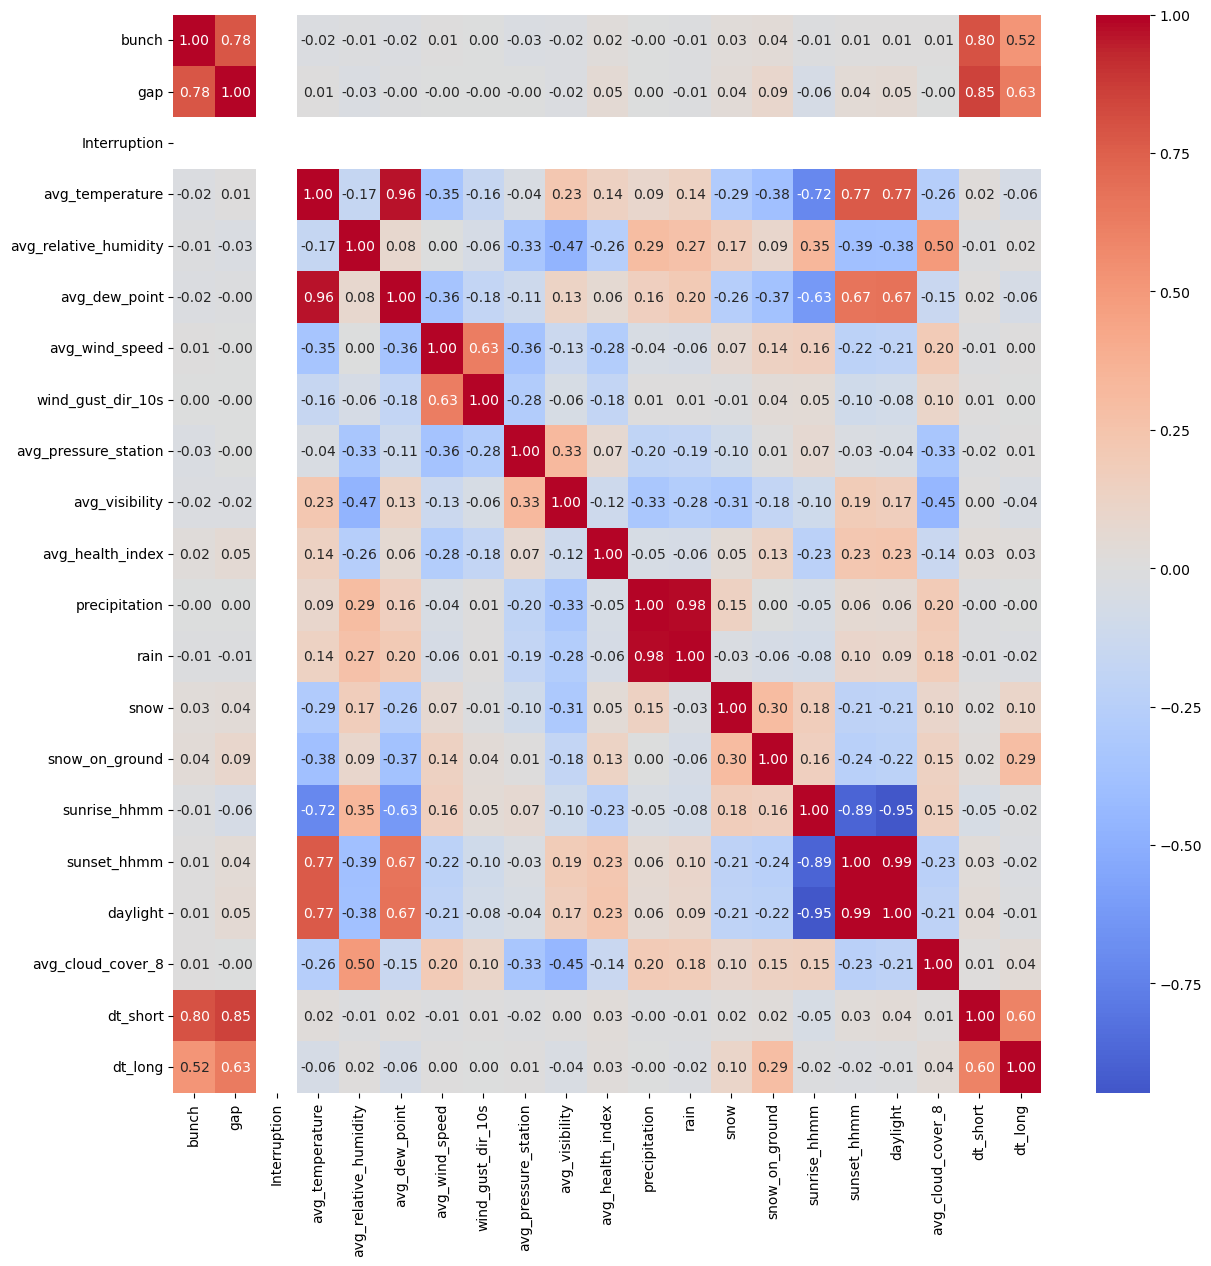

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,14))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f')
plt.show()

Most of these columns are either essentially repeats of other columns, or totally uncorrelated, except for the following features:
- Bunch, Gap, Interruption, avg_temperature, avg_wind_speed, avg_visibility, avg_health_index, rain, snow_on_ground, daylight

Interestingly, factors like windspeed seem to not play any role on the data.

Lets build a model around these features. First let's see a truncated version of the correlation matrix with only these features.

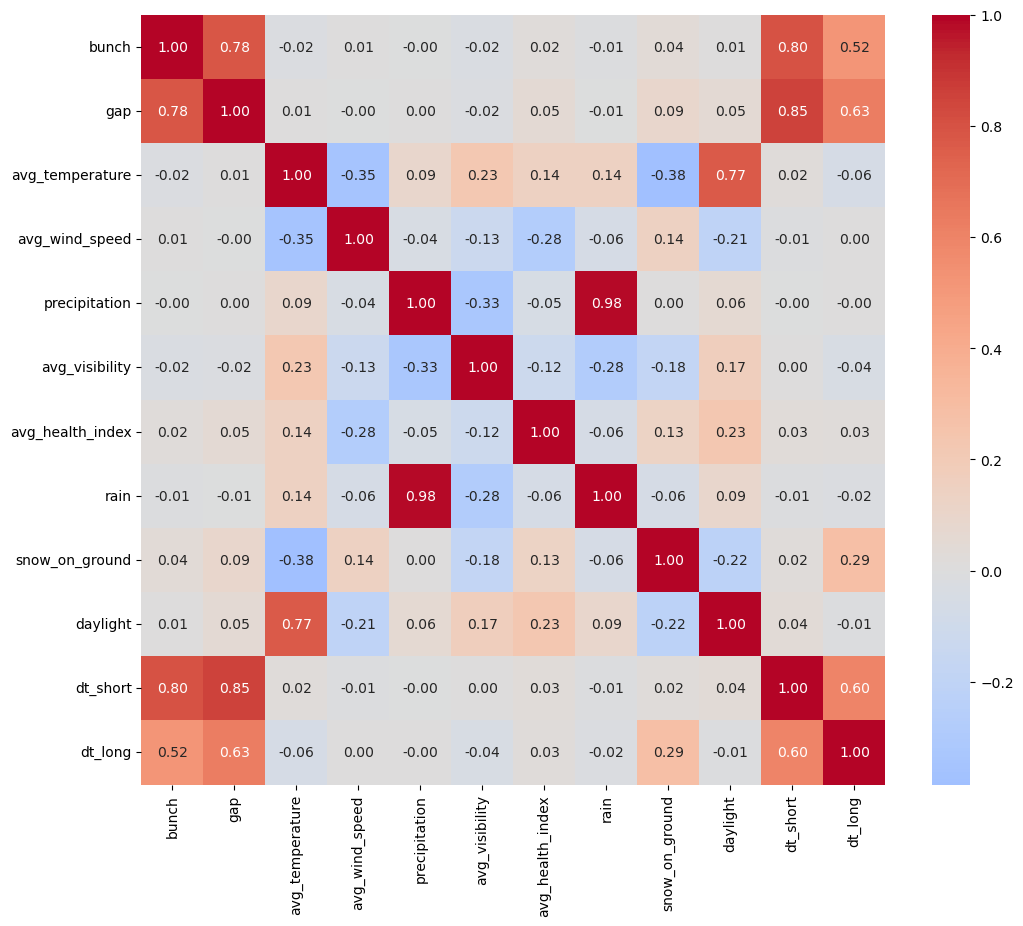

In [15]:
features = ['bunch', 'gap', 'avg_temperature','avg_wind_speed', 'precipitation', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight']
targets = [x for x in daily_df.columns if 'dt_' in x]

corr_matrix = daily_df[features+targets].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f');

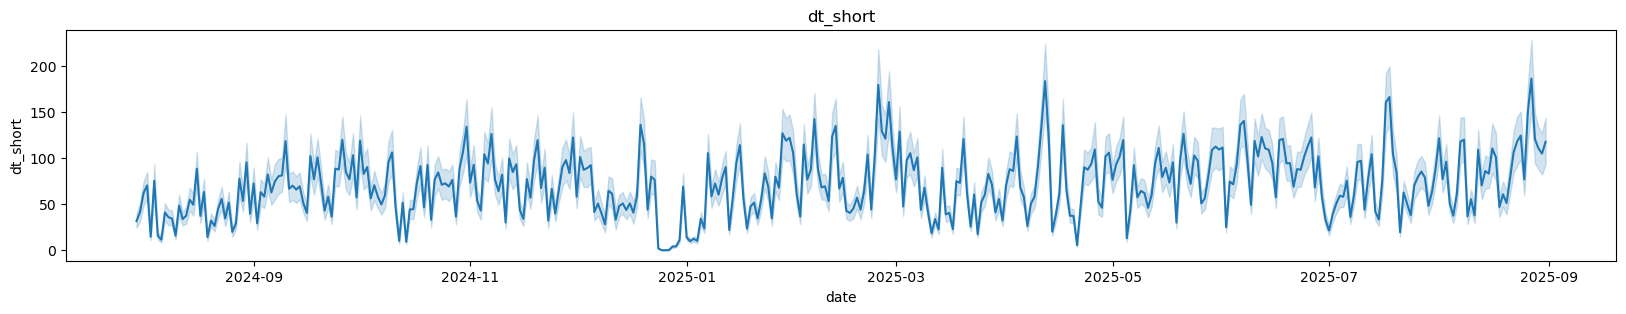

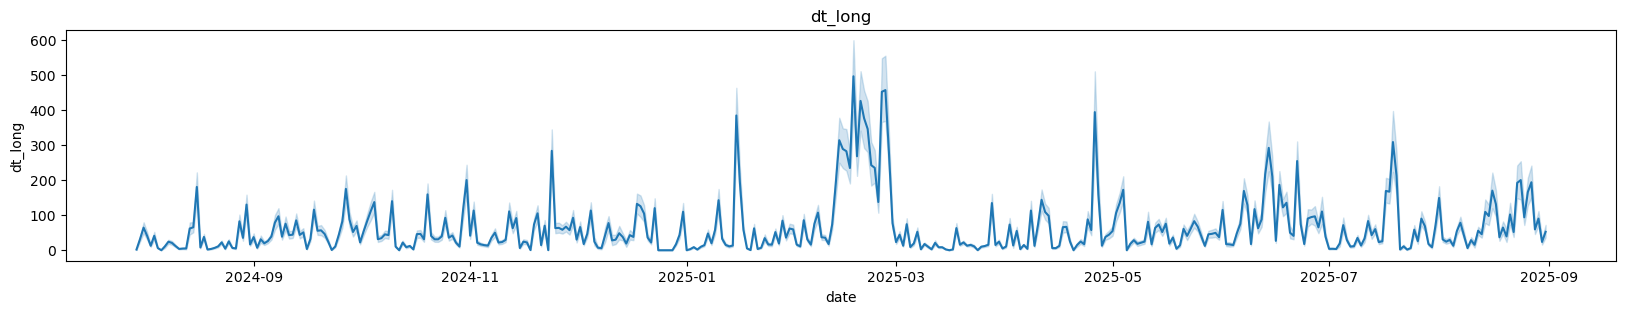

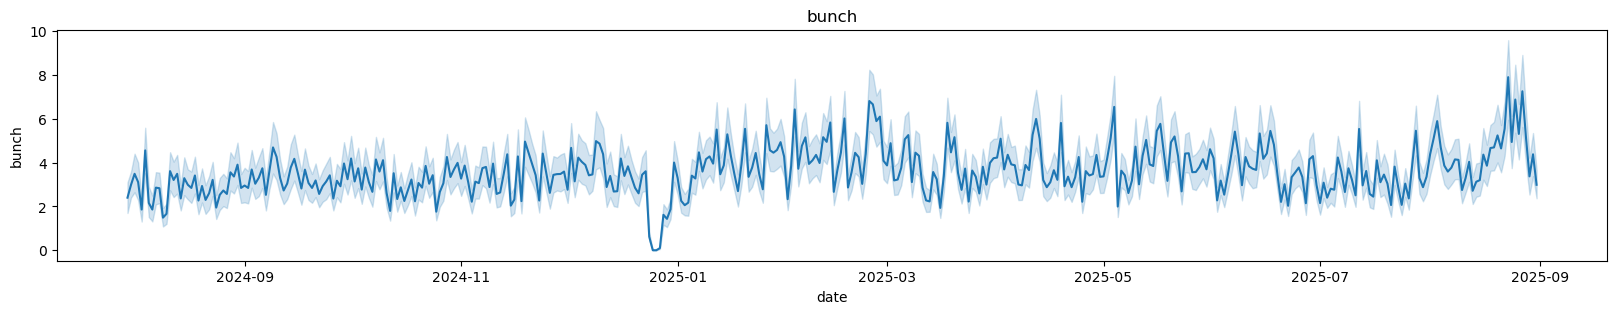

In [16]:
for dt in ['dt_short', 'dt_long']:
    plt.figure(figsize=(20,3))
    sns.lineplot(data=daily_df, x='date', y=dt)
    plt.title(dt)
    plt.show()

plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='bunch')
plt.title('bunch')
plt.show()

Some of the feature of the long term weight can be explained by snowfall.

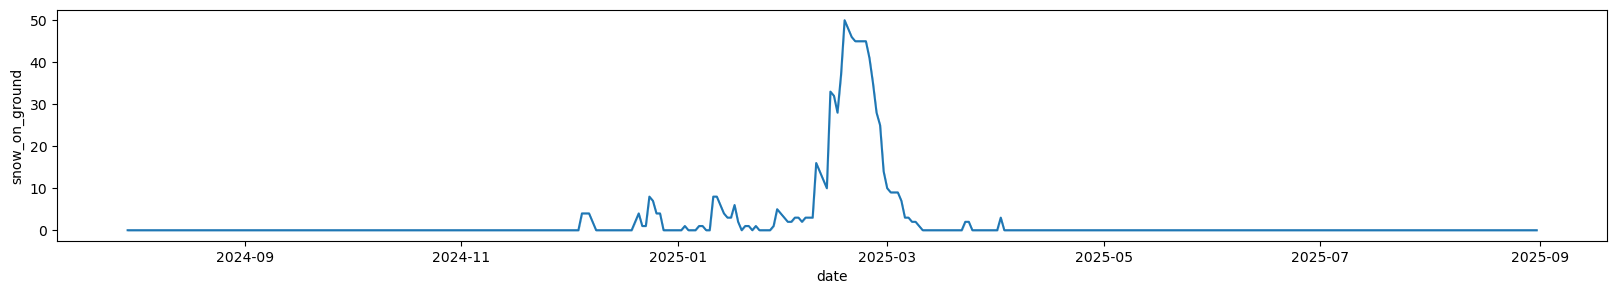

In [17]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='snow_on_ground')
plt.show()

Another region of 'spikes' corresponds to some of the hottest days of the year.

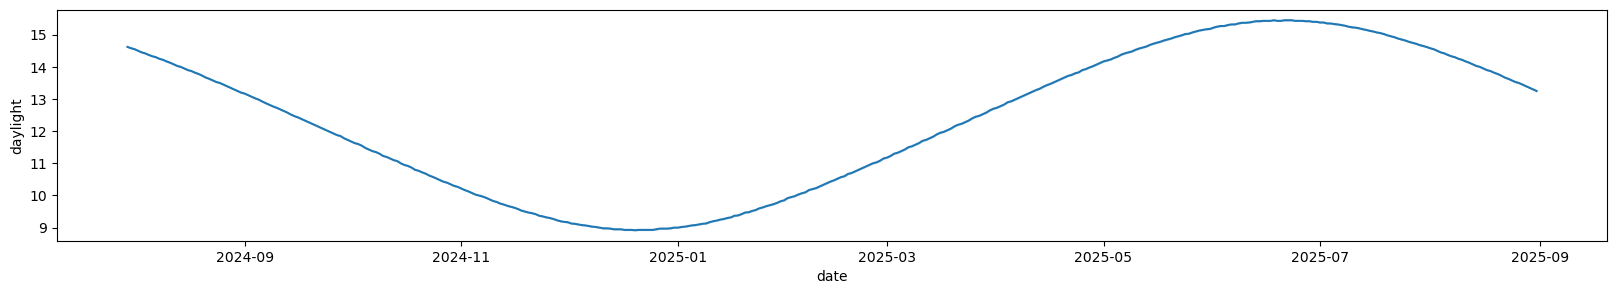

In [18]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='daylight')
plt.show()

The ACF and PACF plots show no strong correlation between bunch events per day.

In [19]:
def count_feature(date, feature, df):
    if len(df[df['date'] == date][feature].tolist())==0:
        return 0
    else:
        return sum(df[df['date'] == date][feature])

bunch_events = []
start_date = daily_df.date.min()
end_date = daily_df.date.max()
timedelta = (end_date - start_date).days
for delta in range(timedelta):
    bunch_events.append(count_feature(start_date+pd.Timedelta(days=delta), 'bunch', daily_df))

bunch_events = np.array(bunch_events)

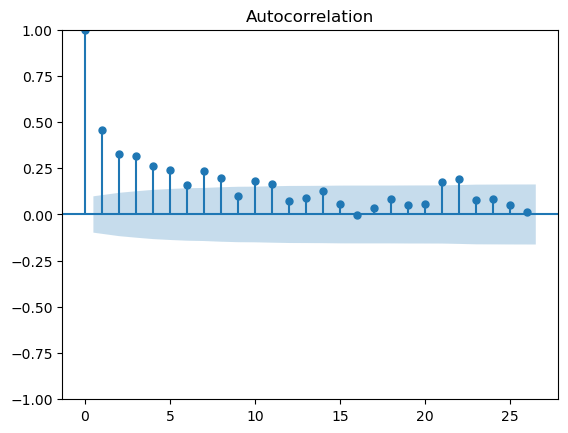

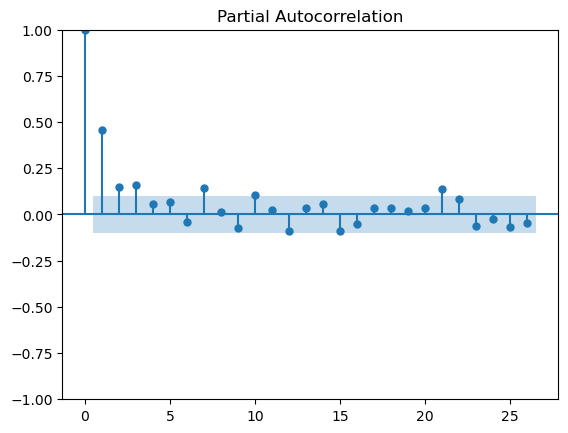

In [20]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
plot_acf(bunch_events)
plt.show()
plot_pacf(bunch_events)
plt.show()

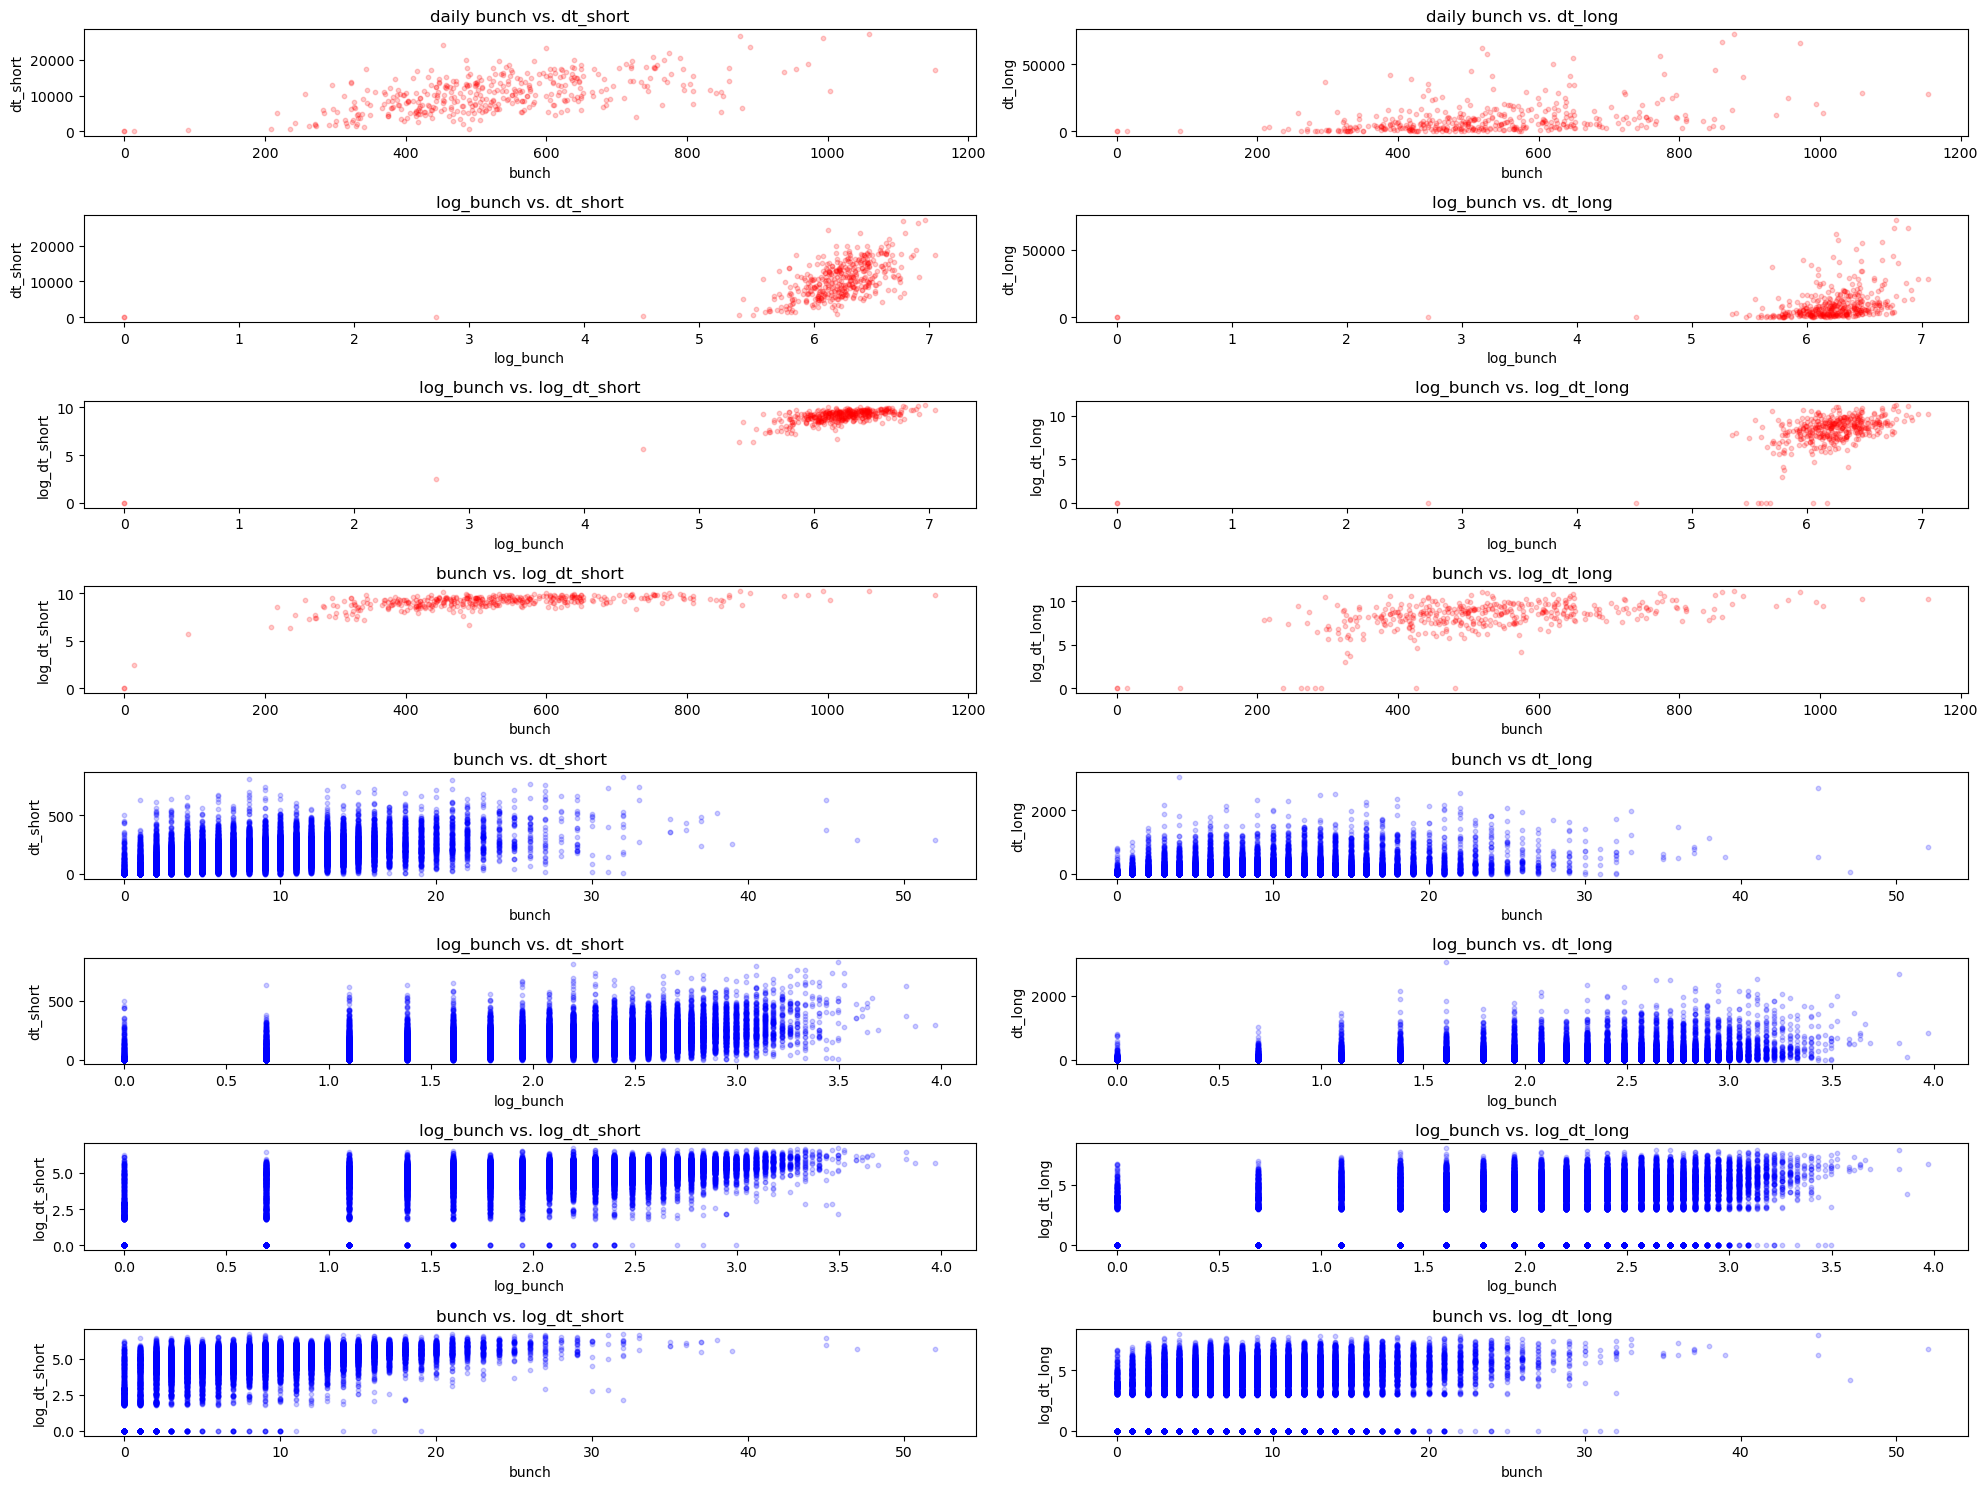

In [21]:
# Lets compare bunch and dt_short with dt_long in a few different ways.

#Calculate totals (sum on minutes delayed and sum of number of occurrences) for each day
daily_stat = (
    daily_df
    .groupby('date')[['bunch','dt_short','dt_long']]
    .sum()
    .reset_index()
)

#We will also look at what happens when we take a log transform of these

# Create transformed variables

daily_df['log_bunch'] = np.log1p(daily_df['bunch'])
daily_df['log_dt_short'] = np.log1p(daily_df['dt_short'])
daily_df['log_dt_long'] = np.log1p(daily_df['dt_long'])


daily_stat['log_bunch'] = np.log1p(daily_stat['bunch'])
daily_stat['log_dt_short'] = np.log1p(daily_stat['dt_short'])
daily_stat['log_dt_long'] = np.log1p(daily_stat['dt_long'])

fig, axes = plt.subplots(8, 2, figsize=(20,15))


# -----------------------------
# Daily totals
# -----------------------------

# gap vs delay
axes[0,0].scatter(
    daily_stat['bunch'],
    daily_stat['dt_short'],
    alpha=0.2,
    s=10,
    color='red'
)
axes[0,0].set_xlabel("bunch")
axes[0,0].set_ylabel("dt_short")
axes[0,0].set_title("daily bunch vs. dt_short")

# bunch vs delay
axes[0,1].scatter(
    daily_stat['bunch'],
    daily_stat['dt_long'],
    alpha=0.2,
    s=10,
    color='red'
)
axes[0,1].set_xlabel("bunch")
axes[0,1].set_ylabel("dt_long")
axes[0,1].set_title("daily bunch vs. dt_long")

# -----------------------------
# Log transforms of bunches
# -----------------------------

# log bunch vs short delay
axes[1,0].scatter(
    daily_stat['log_bunch'],
    daily_stat['dt_short'],
    alpha=0.2,
    s=10,
    color='red'
)
axes[1,0].set_xlabel("log_bunch")
axes[1,0].set_ylabel("dt_short")
axes[1,0].set_title("log_bunch vs. dt_short")

# log bunch vs long delay

axes[1,1].scatter(
    daily_stat['log_bunch'],
    daily_stat['dt_long'],
    alpha=0.2,
    s=10,
    color='red'
)
axes[1,1].set_xlabel("log_bunch")
axes[1,1].set_ylabel("dt_long")
axes[1,1].set_title("log_bunch vs. dt_long")


# -----------------------------
# Log transforms of delays and bunches
# -----------------------------

# log bunch vs log short delay 

axes[2,0].scatter(
    daily_stat['log_bunch'],
    daily_stat['log_dt_short'],
    alpha=0.2,
    s=10,
    color='red'
)
axes[2,0].set_xlabel("log_bunch")
axes[2,0].set_ylabel("log_dt_short")
axes[2,0].set_title("log_bunch vs. log_dt_short")

# log bunch vs log long delay

axes[2,1].scatter(
    daily_stat['log_bunch'],
    daily_stat['log_dt_long'],
    alpha=0.2,
    s=10,
    color='red'
)
axes[2,1].set_xlabel("log_bunch")
axes[2,1].set_ylabel("log_dt_long")
axes[2,1].set_title("log_bunch vs. log_dt_long")

# -----------------------------
# Log transforms of delays 
# -----------------------------

# bunch vs log short delay 

axes[3,0].scatter(
    daily_stat['bunch'],
    daily_stat['log_dt_short'],
    alpha=0.2,
    s=10,
    color='red'
)
axes[3,0].set_xlabel("bunch")
axes[3,0].set_ylabel("log_dt_short")
axes[3,0].set_title("bunch vs. log_dt_short")

#  bunch vs log long delay

axes[3,1].scatter(
    daily_stat['bunch'],
    daily_stat['log_dt_long'],
    alpha=0.2,
    s=10,
    color='red'
)
axes[3,1].set_xlabel("bunch")
axes[3,1].set_ylabel("log_dt_long")
axes[3,1].set_title("bunch vs. log_dt_long")

# -----------------------------
# Individual observations
# -----------------------------


axes[4,0].scatter(
    daily_df['bunch'],
    daily_df['dt_short'],
    alpha=0.2,
    s=10,
    color='blue'
)
axes[4,0].set_xlabel("bunch")
axes[4,0].set_ylabel("dt_short")
axes[4,0].set_title("bunch vs. dt_short")

# bunch vs delay
axes[4,1].scatter(
    daily_df['bunch'],
    daily_df['dt_long'],
    alpha=0.2,
    s=10,
    color='blue'
)
axes[4,1].set_xlabel("bunch")
axes[4,1].set_ylabel("dt_long")
axes[4,1].set_title("bunch vs dt_long")


# -----------------------------
# Log transforms of bunches
# -----------------------------

# log bunch vs short delay
axes[5,0].scatter(
    daily_df['log_bunch'],
    daily_df['dt_short'],
    alpha=0.2,
    s=10,
    color='blue'
)
axes[5,0].set_xlabel("log_bunch")
axes[5,0].set_ylabel("dt_short")
axes[5,0].set_title("log_bunch vs. dt_short")

# log bunch vs long delay

axes[5,1].scatter(
    daily_df['log_bunch'],
    daily_df['dt_long'],
    alpha=0.2,
    s=10,
    color='blue'
)
axes[5,1].set_xlabel("log_bunch")
axes[5,1].set_ylabel("dt_long")
axes[5,1].set_title("log_bunch vs. dt_long")


# -----------------------------
# Log transforms of delays and bunches
# -----------------------------

# log bunch vs log short delay 

axes[6,0].scatter(
    daily_df['log_bunch'],
    daily_df['log_dt_short'],
    alpha=0.2,
    s=10,
    color='blue'
)
axes[6,0].set_xlabel("log_bunch")
axes[6,0].set_ylabel("log_dt_short")
axes[6,0].set_title("log_bunch vs. log_dt_short")

# log bunch vs log long delay

axes[6,1].scatter(
    daily_df['log_bunch'],
    daily_df['log_dt_long'],
    alpha=0.2,
    s=10,
    color='blue'
)
axes[6,1].set_xlabel("log_bunch")
axes[6,1].set_ylabel("log_dt_long")
axes[6,1].set_title("log_bunch vs. log_dt_long")

# -----------------------------
# Log transforms of delays 
# -----------------------------

# bunch vs log short delay 

axes[7,0].scatter(
    daily_df['bunch'],
    daily_df['log_dt_short'],
    alpha=0.2,
    s=10,
    color='blue'
)
axes[7,0].set_xlabel("bunch")
axes[7,0].set_ylabel("log_dt_short")
axes[7,0].set_title("bunch vs. log_dt_short")

#  bunch vs log long delay

axes[7,1].scatter(
    daily_df['bunch'],
    daily_df['log_dt_long'],
    alpha=0.2,
    s=10,
    color='blue'
)
axes[7,1].set_xlabel("bunch")
axes[7,1].set_ylabel("log_dt_long")
axes[7,1].set_title("bunch vs. log_dt_long")
plt.tight_layout()
plt.show()

std_scale__bunch                              83.152772
one_hot_encode__stop_High Park Loop           73.704691
one_hot_encode__stop_Parkside Dr East Side    56.724428
one_hot_encode__stop_Indian Rd                51.211289
one_hot_encode__stop_Roncesvalles Ave         36.275279
                                                ...    
one_hot_encode__stop_McCaul St                 0.611177
one_hot_encode__stop_Spadina Ave              -0.448796
std_scale__avg_wind_speed                     -0.201199
one_hot_encode__stop_Havelock St              -0.153998
std_scale__rain                                0.040359
Length: 83, dtype: float64


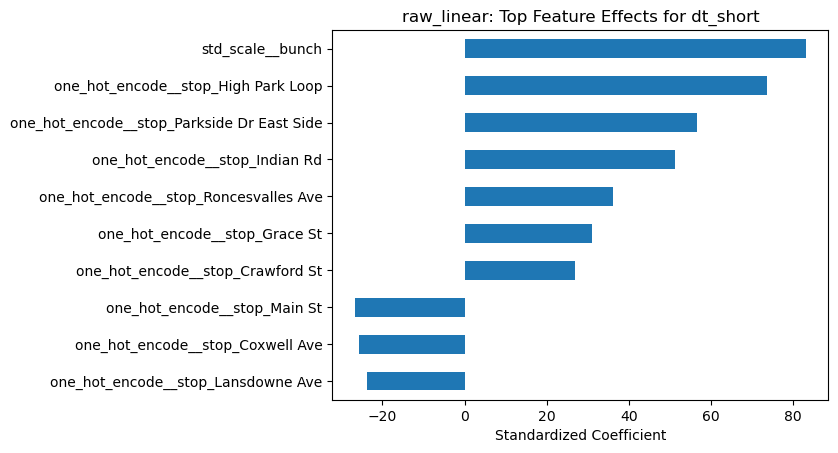

std_scale__bunch                              83.154360
one_hot_encode__stop_High Park Loop           73.688886
one_hot_encode__stop_Parkside Dr East Side    56.708619
one_hot_encode__stop_Indian Rd                51.276913
one_hot_encode__stop_Roncesvalles Ave         36.396103
                                                ...    
one_hot_encode__stop_McCaul St                 0.589426
one_hot_encode__stop_Spadina Ave              -0.477103
std_scale__avg_wind_speed                     -0.228905
one_hot_encode__stop_Havelock St              -0.177917
std_scale__rain                                0.034183
Length: 83, dtype: float64


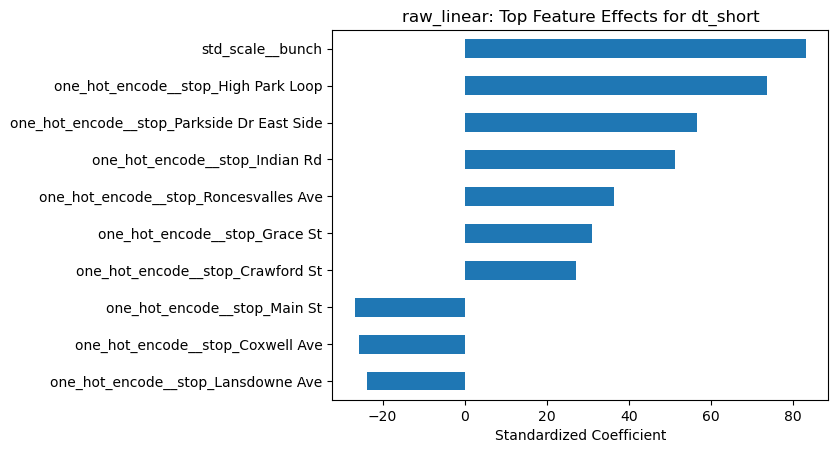

std_scale__bunch                                       83.151031
one_hot_encode__stop_High Park Loop                    73.839617
one_hot_encode__stop_Parkside Dr East Side             56.746683
one_hot_encode__stop_Indian Rd                         51.239213
one_hot_encode__stop_Roncesvalles Ave                  36.358093
                                                         ...    
one_hot_encode__stop_Coxwell Ave at Gerrard St East     0.655377
one_hot_encode__stop_Spadina Ave                       -0.517973
std_scale__avg_wind_speed                              -0.286645
one_hot_encode__stop_Havelock St                       -0.216668
std_scale__rain                                         0.021940
Length: 83, dtype: float64


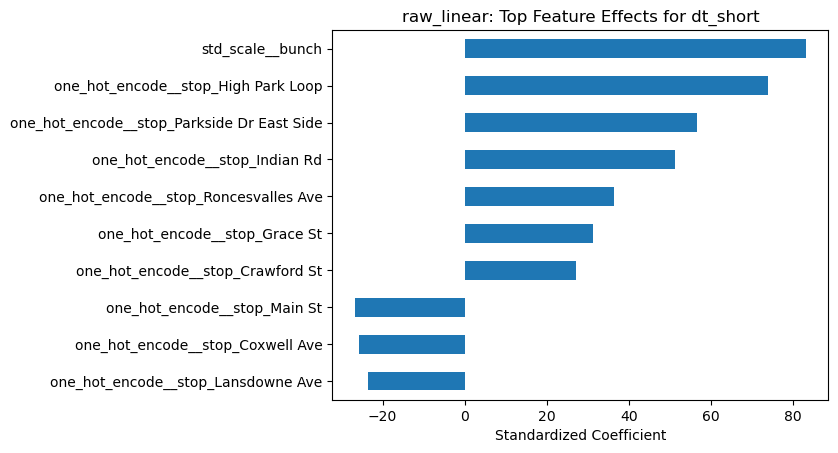

std_scale__bunch                                       83.142497
one_hot_encode__stop_High Park Loop                    73.702054
one_hot_encode__stop_Parkside Dr East Side             56.630596
one_hot_encode__stop_Indian Rd                         51.204550
one_hot_encode__stop_Roncesvalles Ave                  36.323249
                                                         ...    
one_hot_encode__stop_Coxwell Ave at Gerrard St East     0.620831
one_hot_encode__stop_Spadina Ave                       -0.553794
std_scale__avg_wind_speed                              -0.340318
one_hot_encode__stop_Havelock St                       -0.251646
std_scale__rain                                         0.010546
Length: 83, dtype: float64


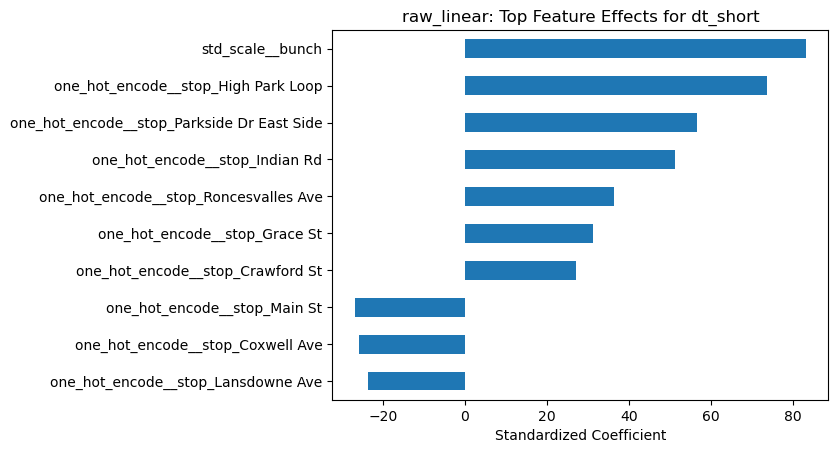

std_scale__bunch                                       83.128659
one_hot_encode__stop_High Park Loop                    73.673103
one_hot_encode__stop_Parkside Dr East Side             56.601642
one_hot_encode__stop_Indian Rd                         51.177589
one_hot_encode__stop_Roncesvalles Ave                  36.296341
                                                         ...    
one_hot_encode__stop_Coxwell Ave at Gerrard St East     0.593392
std_scale__avg_wind_speed                              -0.383217
one_hot_encode__stop_Spadina Ave                       -0.193669
one_hot_encode__stop_Havelock St                       -0.154010
std_scale__rain                                         0.001403
Length: 83, dtype: float64


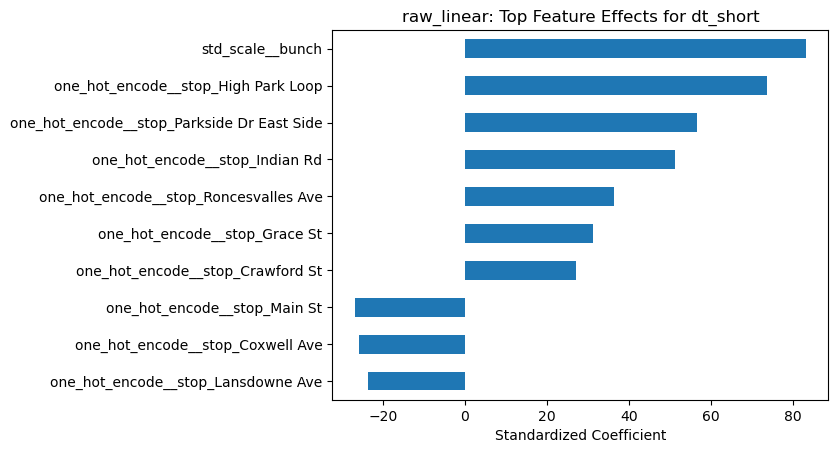

one_hot_encode__stop_High Park Loop                 111.583898
std_scale__bunch                                     80.562861
one_hot_encode__stop_Parkside Dr East Side           66.431993
one_hot_encode__stop_Grace St                        52.201150
std_scale__snow_on_ground                            50.589781
                                                       ...    
one_hot_encode__stop_Parliament St at Carlton St     -2.457762
std_scale__rain                                      -2.177146
one_hot_encode__stop_Bay St                          -1.573497
one_hot_encode__stop_McCaul St                        1.402252
std_scale__avg_visibility                            -0.647048
Length: 83, dtype: float64


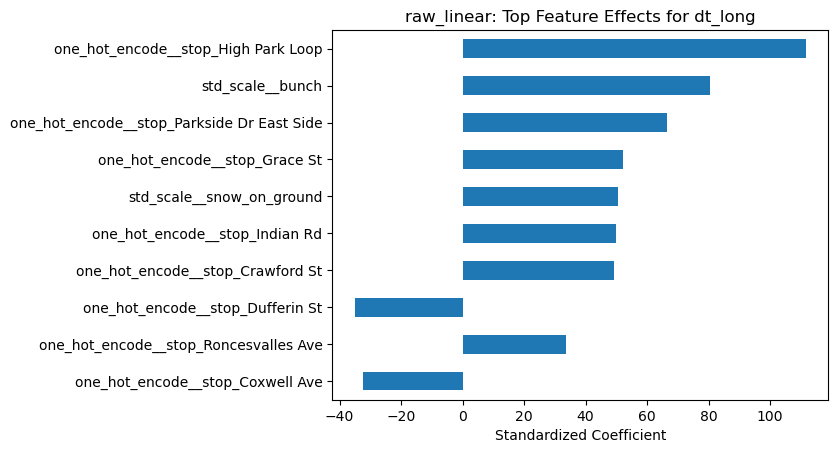

one_hot_encode__stop_High Park Loop                 111.588187
std_scale__bunch                                     80.548908
one_hot_encode__stop_Parkside Dr East Side           66.436284
one_hot_encode__stop_Grace St                        52.208819
std_scale__snow_on_ground                            50.576931
                                                       ...    
one_hot_encode__stop_Parliament St at Carlton St     -2.457292
std_scale__rain                                      -2.174746
one_hot_encode__stop_Bay St                          -1.597396
one_hot_encode__stop_McCaul St                        1.410098
std_scale__avg_visibility                            -0.649720
Length: 83, dtype: float64


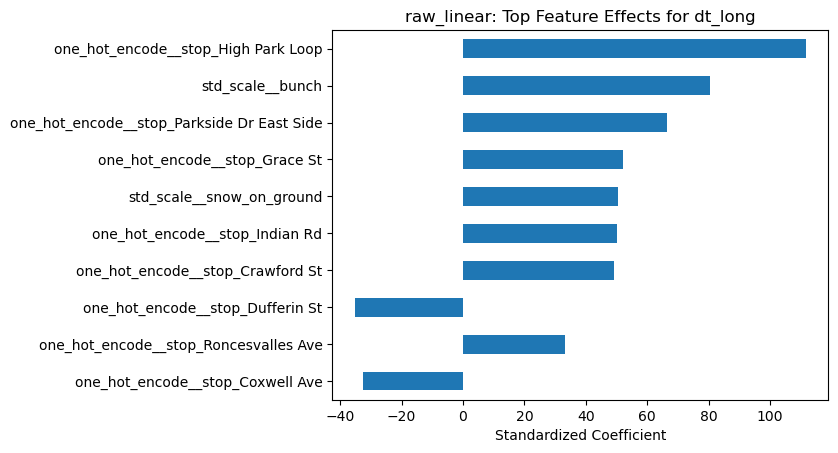

one_hot_encode__stop_High Park Loop                 112.496346
std_scale__bunch                                     80.555601
one_hot_encode__stop_Parkside Dr East Side           66.822696
one_hot_encode__stop_Grace St                        52.345883
std_scale__snow_on_ground                            50.566900
                                                       ...    
one_hot_encode__stop_Parliament St at Carlton St     -2.473082
std_scale__rain                                      -2.178283
one_hot_encode__stop_Bay St                          -1.622727
one_hot_encode__stop_McCaul St                        1.363873
std_scale__avg_visibility                            -0.645346
Length: 83, dtype: float64


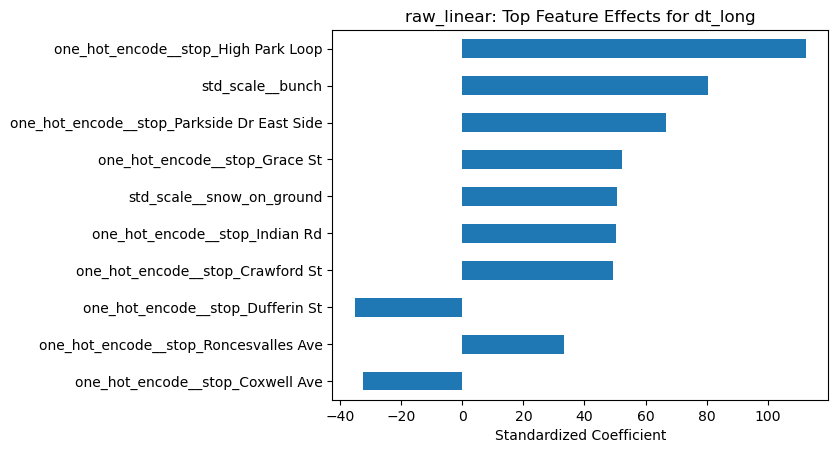

one_hot_encode__stop_High Park Loop                 112.350620
std_scale__bunch                                     80.533038
one_hot_encode__stop_Parkside Dr East Side           66.734337
one_hot_encode__stop_Grace St                        52.359206
std_scale__snow_on_ground                            50.552913
                                                       ...    
one_hot_encode__stop_Parliament St at Carlton St     -2.458991
std_scale__rain                                      -2.174091
one_hot_encode__stop_Bay St                          -1.600462
one_hot_encode__stop_McCaul St                        1.377567
std_scale__avg_visibility                            -0.649141
Length: 83, dtype: float64


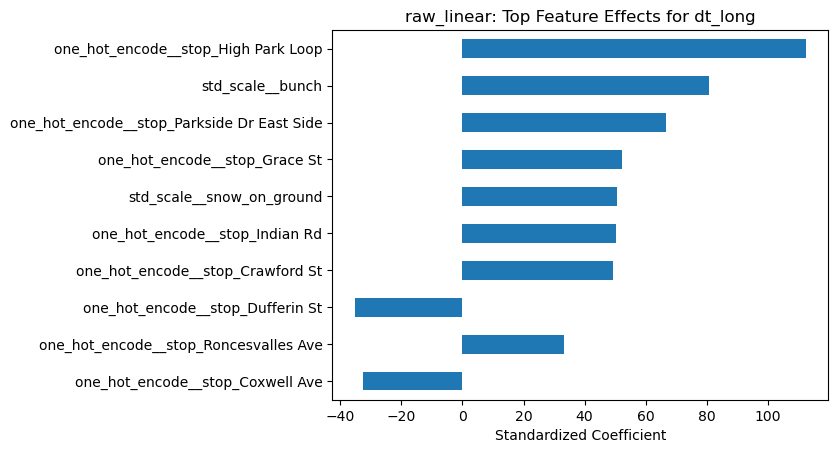

one_hot_encode__stop_High Park Loop                 112.351664
std_scale__bunch                                     80.515753
one_hot_encode__stop_Parkside Dr East Side           66.735375
one_hot_encode__stop_Grace St                        52.364319
std_scale__snow_on_ground                            50.540235
                                                       ...    
one_hot_encode__stop_Parliament St at Carlton St     -2.453436
std_scale__rain                                      -2.172305
one_hot_encode__stop_Bay St                          -1.590200
one_hot_encode__stop_McCaul St                        1.382893
std_scale__avg_visibility                            -0.650476
Length: 83, dtype: float64


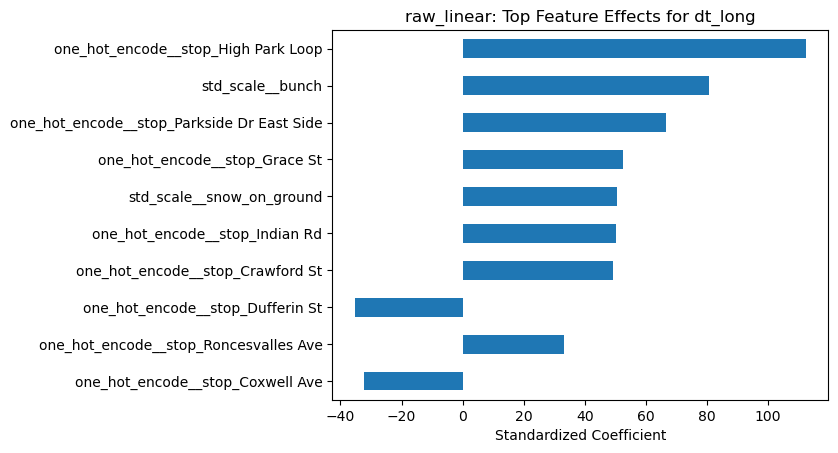

std_scale__bunch                                       1.847746
one_hot_encode__stop_Indian Rd                         1.774657
one_hot_encode__stop_Roncesvalles Ave                  1.594095
one_hot_encode__stop_Parkside Dr East Side             1.329493
one_hot_encode__stop_Dundas St West at Sorauren Ave    1.263198
                                                         ...   
std_scale__snow_on_ground                             -0.029426
std_scale__avg_visibility                              0.028749
std_scale__avg_temperature                            -0.025159
std_scale__avg_wind_speed                              0.017967
std_scale__rain                                        0.007097
Length: 83, dtype: float64


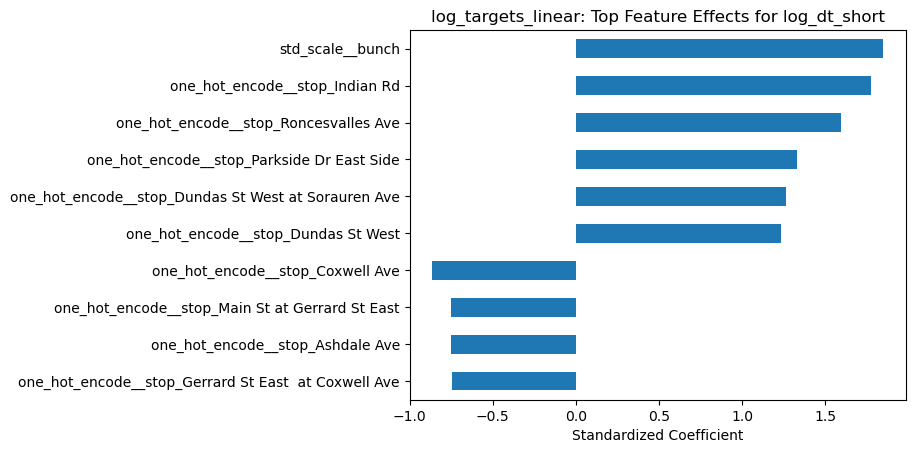

std_scale__bunch                                       1.847695
one_hot_encode__stop_Indian Rd                         1.775437
one_hot_encode__stop_Roncesvalles Ave                  1.597845
one_hot_encode__stop_Parkside Dr East Side             1.329363
one_hot_encode__stop_Dundas St West at Sorauren Ave    1.262972
                                                         ...   
std_scale__snow_on_ground                             -0.029391
std_scale__avg_visibility                              0.028814
std_scale__avg_temperature                            -0.025193
std_scale__avg_wind_speed                              0.017714
std_scale__rain                                        0.007039
Length: 83, dtype: float64


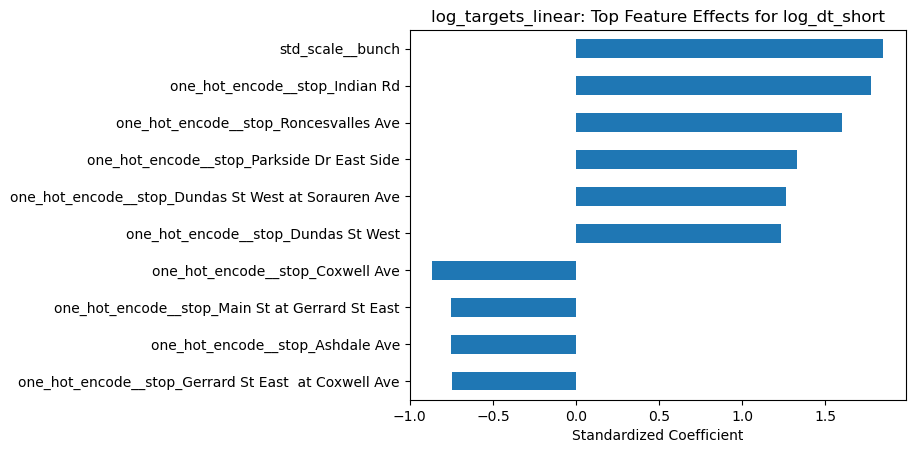

std_scale__bunch                                       1.847602
one_hot_encode__stop_Indian Rd                         1.775041
one_hot_encode__stop_Roncesvalles Ave                  1.597444
one_hot_encode__stop_Parkside Dr East Side             1.331195
one_hot_encode__stop_Dundas St West at Sorauren Ave    1.262564
                                                         ...   
std_scale__snow_on_ground                             -0.029312
std_scale__avg_visibility                              0.028935
std_scale__avg_temperature                            -0.025271
std_scale__avg_wind_speed                              0.017118
std_scale__rain                                        0.006911
Length: 83, dtype: float64


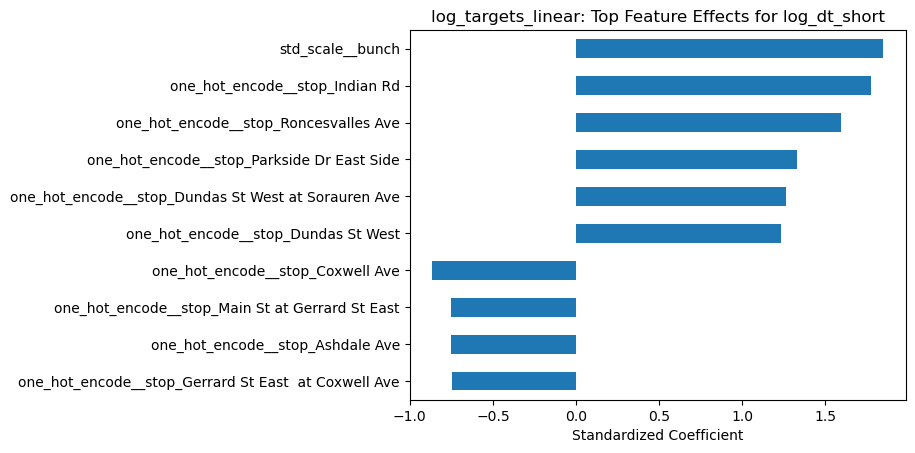

std_scale__bunch                                       1.847482
one_hot_encode__stop_Indian Rd                         1.774589
one_hot_encode__stop_Roncesvalles Ave                  1.596985
one_hot_encode__stop_Parkside Dr East Side             1.328697
one_hot_encode__stop_Dundas St West at Sorauren Ave    1.264255
                                                         ...   
std_scale__snow_on_ground                             -0.029223
std_scale__avg_visibility                              0.029073
std_scale__avg_temperature                            -0.025359
std_scale__avg_wind_speed                              0.016440
std_scale__rain                                        0.006765
Length: 83, dtype: float64


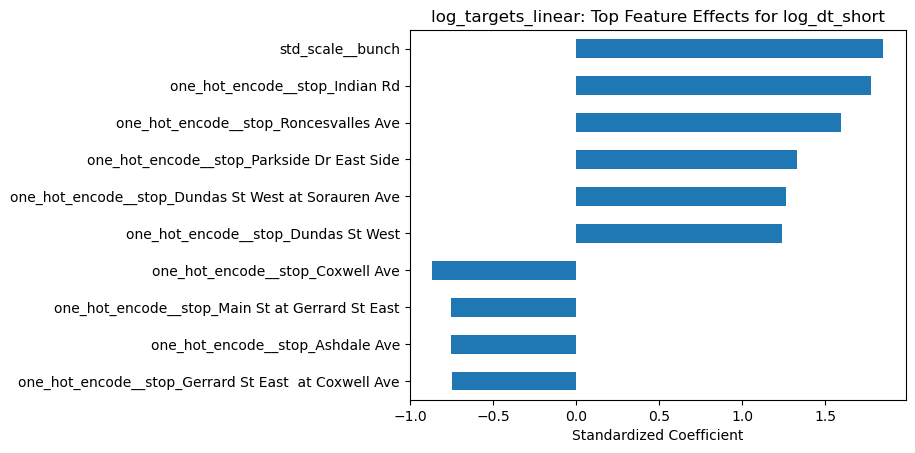

std_scale__bunch                                       1.847244
one_hot_encode__stop_Indian Rd                         1.774252
one_hot_encode__stop_Roncesvalles Ave                  1.596648
one_hot_encode__stop_Parkside Dr East Side             1.328356
one_hot_encode__stop_Dundas St West at Sorauren Ave    1.266039
                                                         ...   
std_scale__avg_visibility                              0.029178
std_scale__snow_on_ground                             -0.029150
std_scale__avg_temperature                            -0.025431
std_scale__avg_wind_speed                              0.015916
std_scale__rain                                        0.006652
Length: 83, dtype: float64


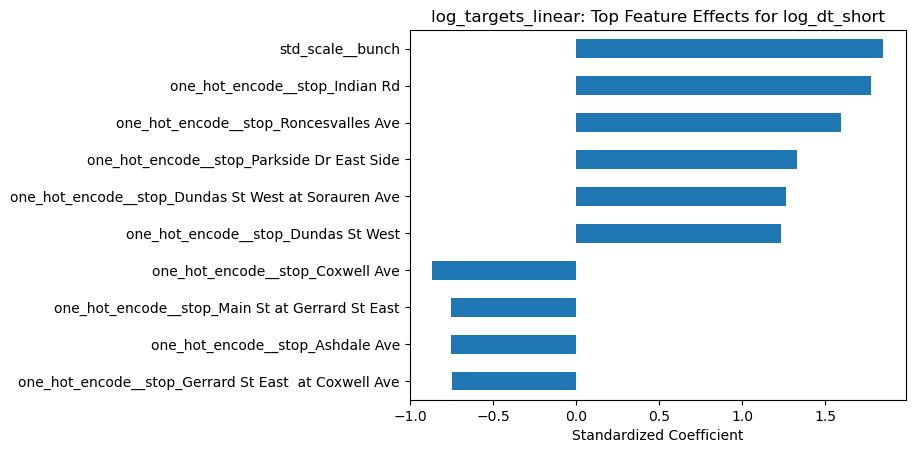

std_scale__bunch                              1.579770
one_hot_encode__stop_Indian Rd                1.370496
one_hot_encode__stop_Parkside Dr East Side    1.245961
one_hot_encode__stop_Roncesvalles Ave         1.197778
one_hot_encode__stop_Dundas St West           0.896663
                                                ...   
one_hot_encode__stop_Broadview Ave           -0.005890
one_hot_encode__stop_St George St            -0.005262
one_hot_encode__stop_De Grassi St             0.003578
std_scale__avg_visibility                    -0.003045
std_scale__daylight                           0.002716
Length: 83, dtype: float64


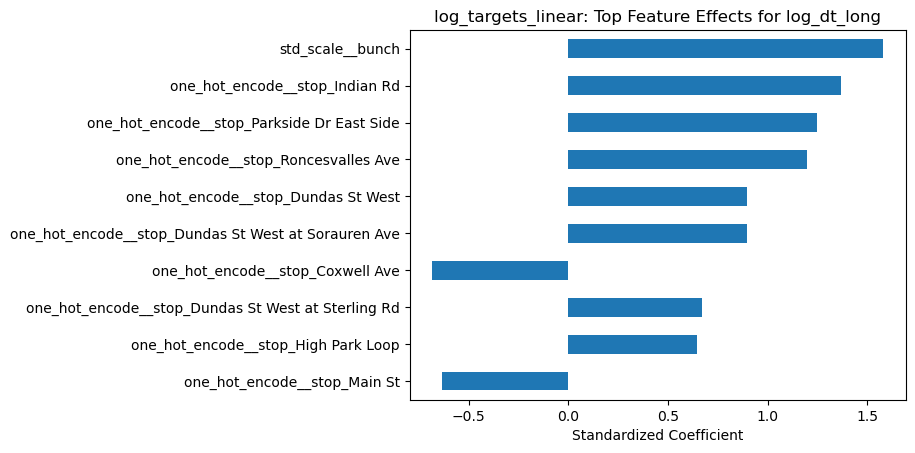

std_scale__bunch                              1.579660
one_hot_encode__stop_Indian Rd                1.373019
one_hot_encode__stop_Parkside Dr East Side    1.245913
one_hot_encode__stop_Roncesvalles Ave         1.196352
one_hot_encode__stop_Dundas St West           0.896584
                                                ...   
one_hot_encode__stop_Broadview Ave           -0.005974
one_hot_encode__stop_St George St            -0.005346
one_hot_encode__stop_De Grassi St             0.003495
std_scale__avg_visibility                    -0.003021
std_scale__daylight                           0.002753
Length: 83, dtype: float64


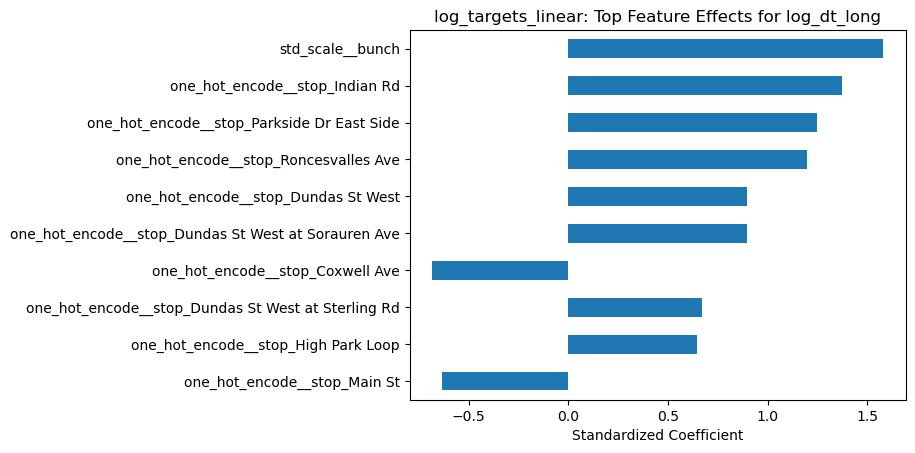

std_scale__bunch                              1.579606
one_hot_encode__stop_Indian Rd                1.372636
one_hot_encode__stop_Parkside Dr East Side    1.249511
one_hot_encode__stop_Roncesvalles Ave         1.195964
one_hot_encode__stop_Dundas St West           0.898900
                                                ...   
one_hot_encode__stop_Broadview Ave           -0.006373
one_hot_encode__stop_St George St            -0.006104
one_hot_encode__stop_De Grassi St             0.003099
std_scale__daylight                           0.002959
std_scale__avg_visibility                    -0.002901
Length: 83, dtype: float64


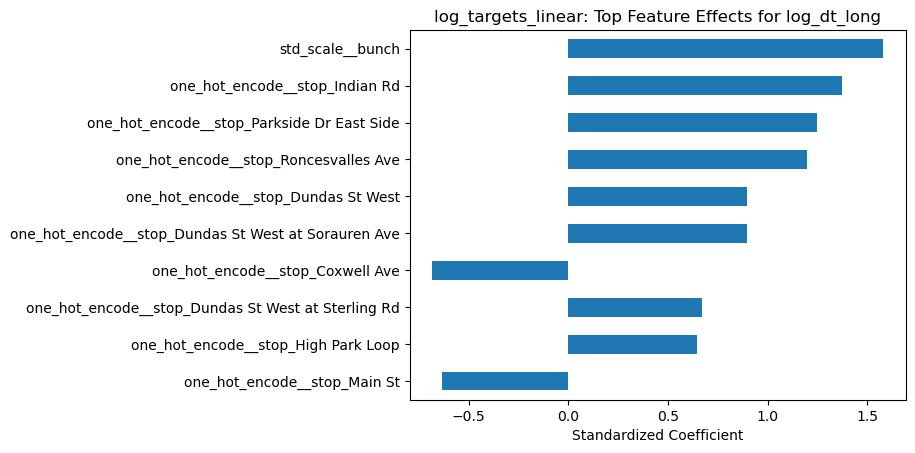

std_scale__bunch                              1.579366
one_hot_encode__stop_Indian Rd                1.372442
one_hot_encode__stop_Parkside Dr East Side    1.247358
one_hot_encode__stop_Roncesvalles Ave         1.195771
one_hot_encode__stop_Dundas St West           0.895395
                                                ...   
one_hot_encode__stop_Broadview Ave           -0.006559
one_hot_encode__stop_St George St            -0.006289
one_hot_encode__stop_De Grassi St             0.006130
std_scale__daylight                           0.003076
std_scale__avg_visibility                    -0.002837
Length: 83, dtype: float64


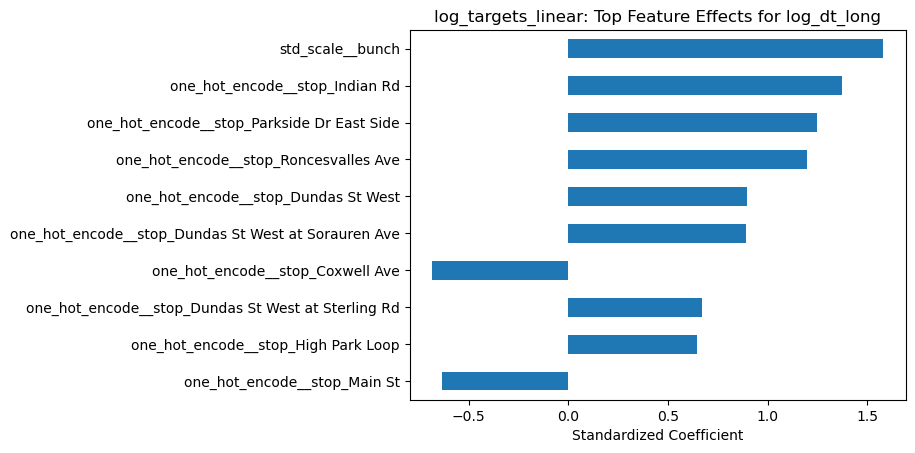

std_scale__bunch                              1.579146
one_hot_encode__stop_Indian Rd                1.372222
one_hot_encode__stop_Parkside Dr East Side    1.247124
one_hot_encode__stop_Roncesvalles Ave         1.195551
one_hot_encode__stop_Dundas St West           0.895175
                                                ...   
one_hot_encode__stop_St George St            -0.006505
one_hot_encode__stop_De Grassi St             0.005913
std_scale__daylight                           0.003205
one_hot_encode__stop_Broadview Ave           -0.003177
std_scale__avg_visibility                    -0.002766
Length: 83, dtype: float64


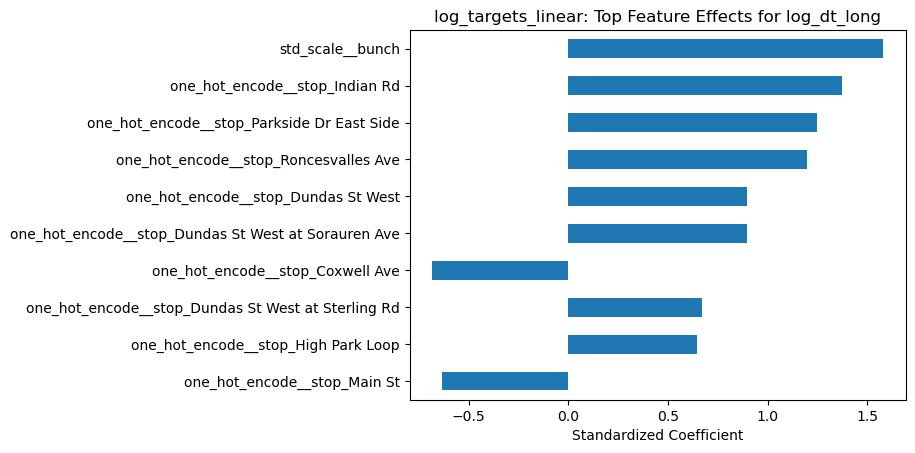

std_scale__log_bunch                          2.260738
one_hot_encode__stop_Indian Rd                1.166915
one_hot_encode__stop_Parkside Dr East Side    1.144724
one_hot_encode__stop_Roncesvalles Ave         0.796430
one_hot_encode__stop_High Park Loop           0.630928
                                                ...   
std_scale__snow_on_ground                    -0.008032
std_scale__rain                               0.004691
std_scale__avg_temperature                    0.002422
std_scale__avg_wind_speed                     0.001859
one_hot_encode__stop_Brock Ave               -0.000829
Length: 83, dtype: float64


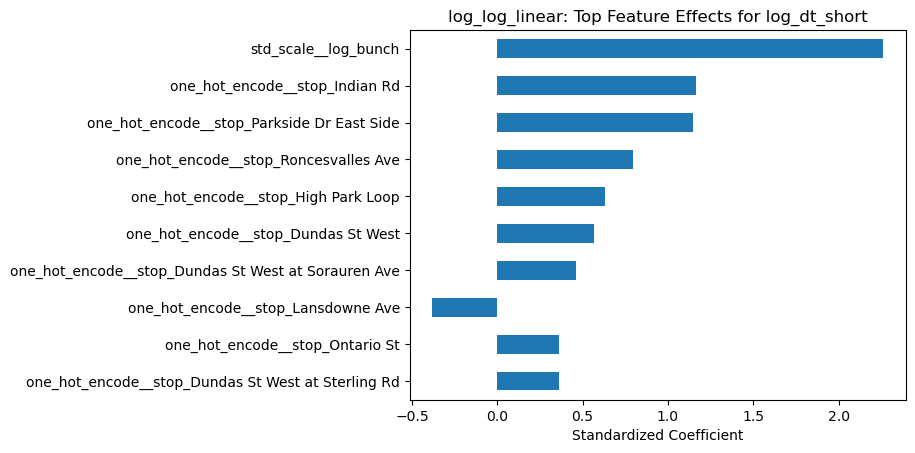

std_scale__log_bunch                          2.260788
one_hot_encode__stop_Indian Rd                1.167039
one_hot_encode__stop_Parkside Dr East Side    1.144634
one_hot_encode__stop_Roncesvalles Ave         0.798812
one_hot_encode__stop_High Park Loop           0.630855
                                                ...   
std_scale__snow_on_ground                    -0.008010
std_scale__rain                               0.004650
std_scale__avg_temperature                    0.002398
std_scale__avg_wind_speed                     0.001677
one_hot_encode__stop_Brock Ave               -0.000999
Length: 83, dtype: float64


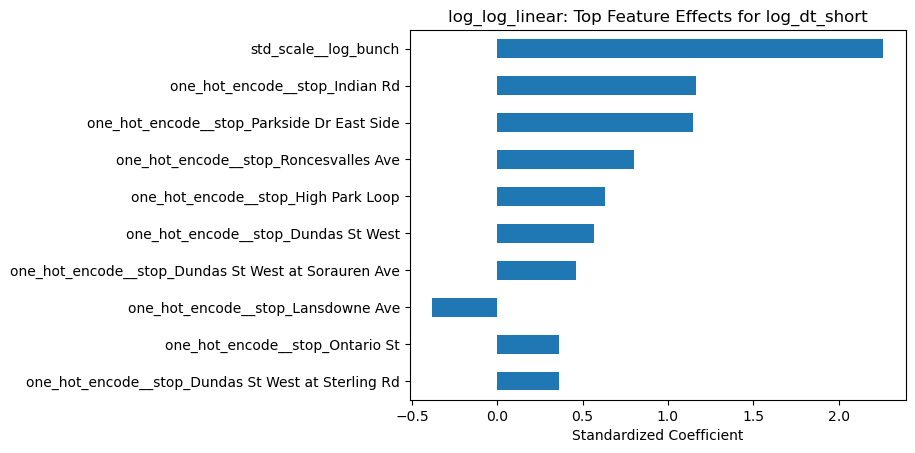

std_scale__log_bunch                          2.260819
one_hot_encode__stop_Indian Rd                1.166709
one_hot_encode__stop_Parkside Dr East Side    1.145542
one_hot_encode__stop_Roncesvalles Ave         0.798464
one_hot_encode__stop_High Park Loop           0.630988
                                                ...   
std_scale__snow_on_ground                    -0.007955
std_scale__rain                               0.004558
std_scale__avg_temperature                    0.002343
one_hot_encode__stop_Brock Ave               -0.001484
std_scale__avg_wind_speed                     0.001245
Length: 83, dtype: float64


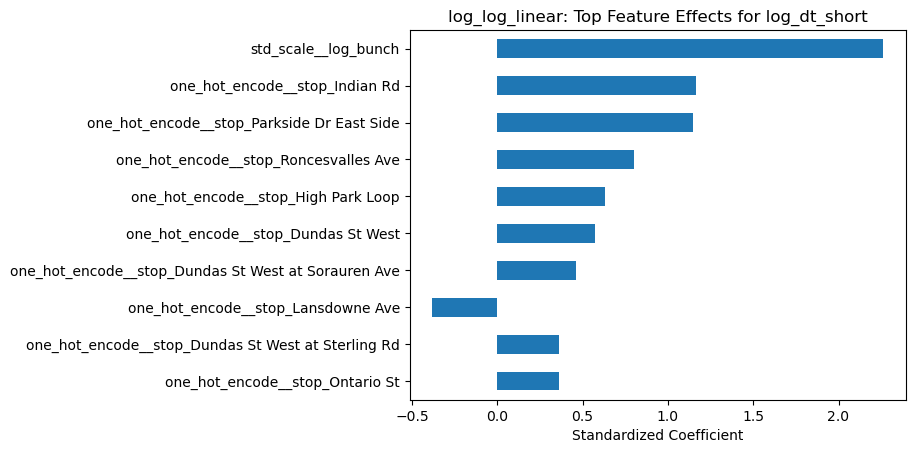

std_scale__log_bunch                          2.260980
one_hot_encode__stop_Indian Rd                1.166377
one_hot_encode__stop_Parkside Dr East Side    1.143743
one_hot_encode__stop_Roncesvalles Ave         0.798106
one_hot_encode__stop_High Park Loop           0.629862
                                                ...   
std_scale__snow_on_ground                    -0.007908
std_scale__rain                               0.004477
std_scale__avg_temperature                    0.002298
one_hot_encode__stop_Brock Ave               -0.001796
std_scale__avg_wind_speed                     0.000859
Length: 83, dtype: float64


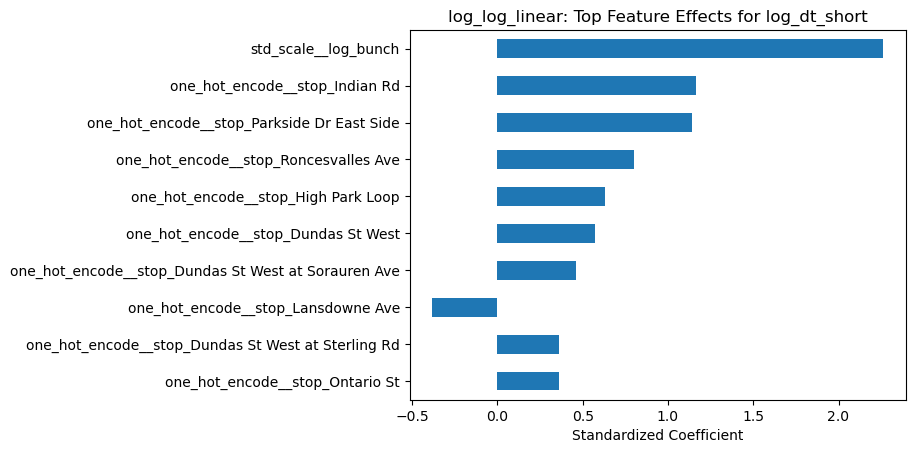

std_scale__log_bunch                          2.260981
one_hot_encode__stop_Indian Rd                1.166119
one_hot_encode__stop_Parkside Dr East Side    1.143557
one_hot_encode__stop_Roncesvalles Ave         0.797834
one_hot_encode__stop_High Park Loop           0.629689
                                                ...   
std_scale__snow_on_ground                    -0.007866
std_scale__rain                               0.004405
std_scale__avg_temperature                    0.002255
one_hot_encode__stop_Brock Ave               -0.001492
std_scale__avg_wind_speed                     0.000524
Length: 83, dtype: float64


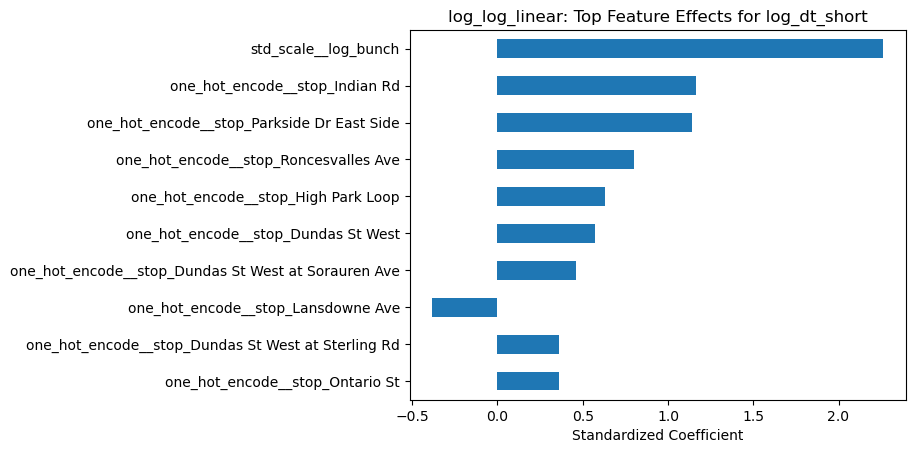

std_scale__log_bunch                                   1.845084
one_hot_encode__stop_Parkside Dr East Side             1.065380
one_hot_encode__stop_Indian Rd                         0.884917
one_hot_encode__stop_High Park Loop                    0.681272
one_hot_encode__stop_Roncesvalles Ave                  0.560208
                                                         ...   
one_hot_encode__stop_McCaul St                         0.010013
one_hot_encode__stop_Spadina Ave                      -0.009363
std_scale__avg_visibility                             -0.004027
std_scale__avg_health_index                           -0.000900
one_hot_encode__stop_Coxwell Ave at Gerrard St East   -0.000540
Length: 83, dtype: float64


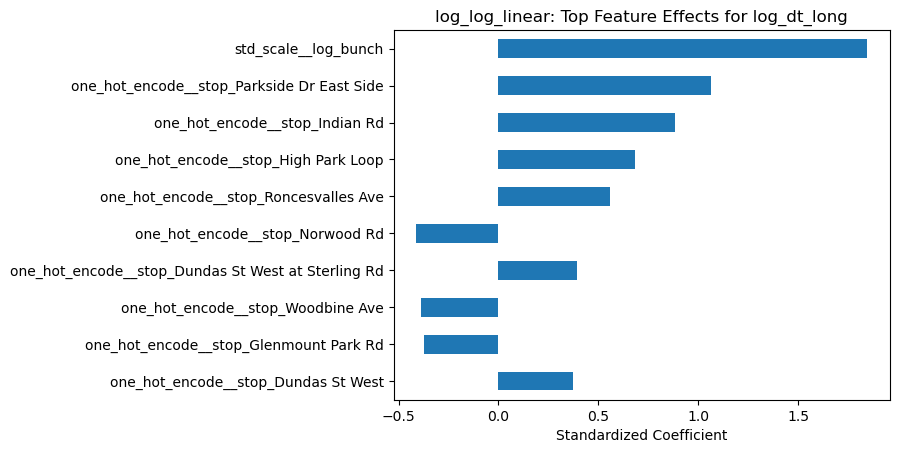

std_scale__log_bunch                                   1.845026
one_hot_encode__stop_Parkside Dr East Side             1.065365
one_hot_encode__stop_Indian Rd                         0.886916
one_hot_encode__stop_High Park Loop                    0.681260
one_hot_encode__stop_Roncesvalles Ave                  0.557674
                                                         ...   
one_hot_encode__stop_McCaul St                         0.009989
one_hot_encode__stop_Spadina Ave                      -0.009399
std_scale__avg_visibility                             -0.004021
std_scale__avg_health_index                           -0.000926
one_hot_encode__stop_Coxwell Ave at Gerrard St East   -0.000561
Length: 83, dtype: float64


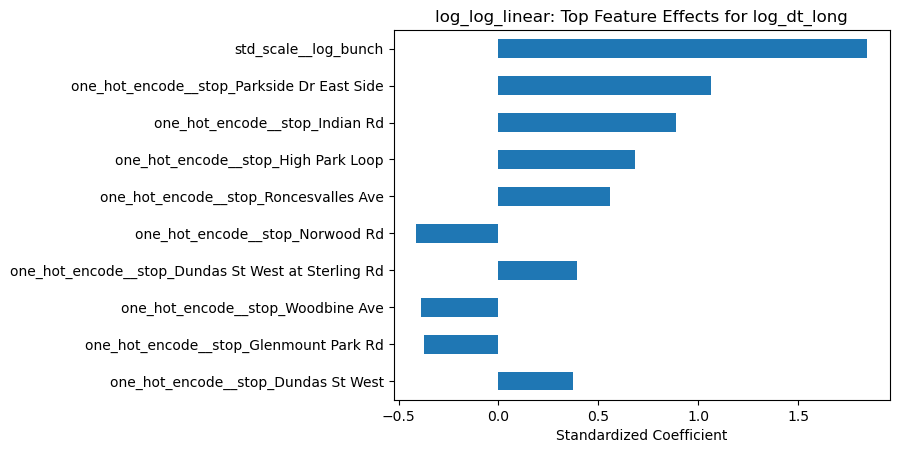

std_scale__log_bunch                                   1.845134
one_hot_encode__stop_Parkside Dr East Side             1.068221
one_hot_encode__stop_Indian Rd                         0.886564
one_hot_encode__stop_High Park Loop                    0.683725
one_hot_encode__stop_Roncesvalles Ave                  0.557298
                                                         ...   
one_hot_encode__stop_McCaul St                         0.010993
one_hot_encode__stop_Spadina Ave                      -0.009849
std_scale__avg_visibility                             -0.003930
std_scale__avg_health_index                           -0.001279
one_hot_encode__stop_Coxwell Ave at Gerrard St East    0.000618
Length: 83, dtype: float64


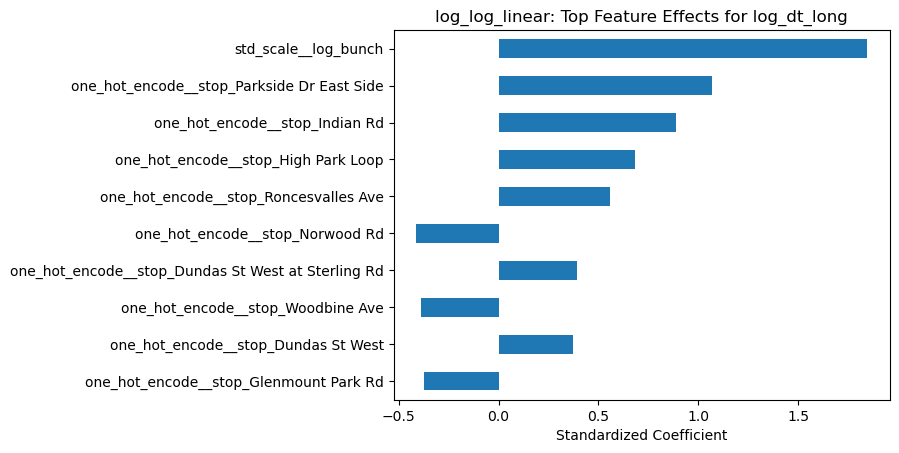

std_scale__log_bunch                                   1.845049
one_hot_encode__stop_Parkside Dr East Side             1.066650
one_hot_encode__stop_Indian Rd                         0.886533
one_hot_encode__stop_High Park Loop                    0.682633
one_hot_encode__stop_Roncesvalles Ave                  0.557272
                                                         ...   
one_hot_encode__stop_McCaul St                         0.010956
one_hot_encode__stop_Spadina Ave                      -0.009859
std_scale__avg_visibility                             -0.003915
std_scale__avg_health_index                           -0.001335
one_hot_encode__stop_Coxwell Ave at Gerrard St East    0.000578
Length: 83, dtype: float64


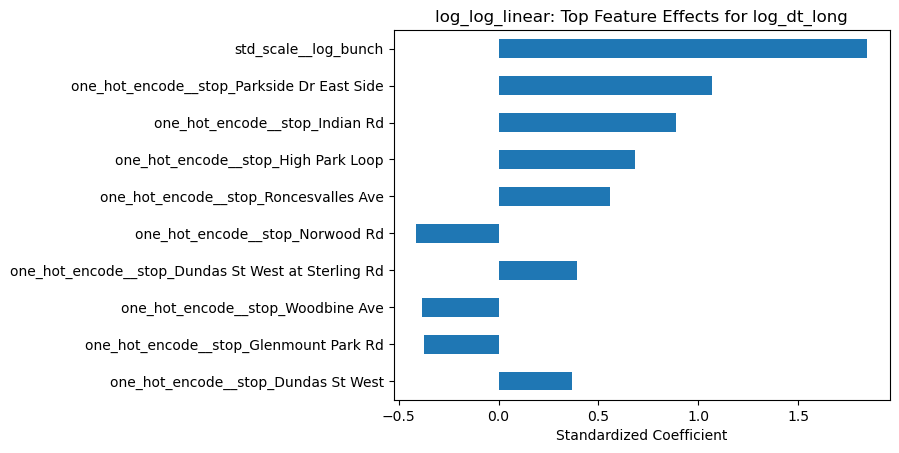

std_scale__log_bunch                                   1.844978
one_hot_encode__stop_Parkside Dr East Side             1.066537
one_hot_encode__stop_Indian Rd                         0.886407
one_hot_encode__stop_High Park Loop                    0.682523
one_hot_encode__stop_Roncesvalles Ave                  0.557143
                                                         ...   
one_hot_encode__stop_McCaul St                         0.010833
one_hot_encode__stop_Spadina Ave                      -0.007161
std_scale__avg_visibility                             -0.003877
std_scale__avg_health_index                           -0.001485
one_hot_encode__stop_Coxwell Ave at Gerrard St East    0.000457
Length: 83, dtype: float64


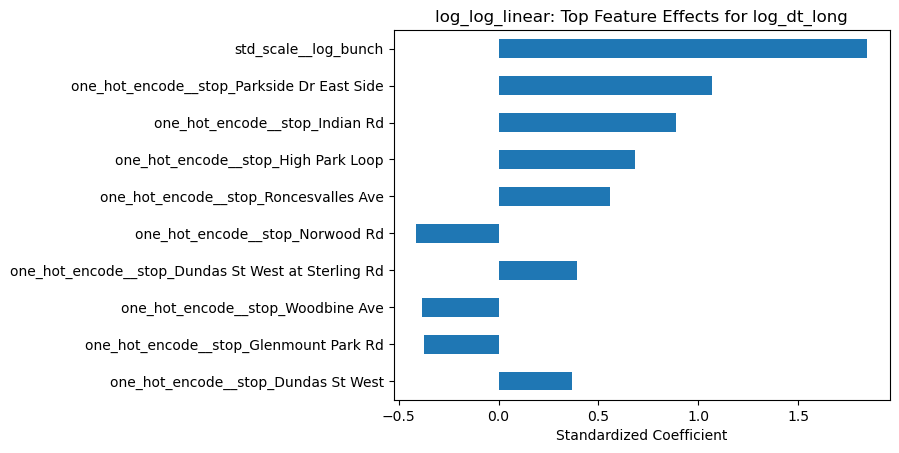

std_scale__log_bunch                                       91.065151
one_hot_encode__stop_High Park Loop                        73.416472
one_hot_encode__stop_Parkside Dr East Side                 45.660387
one_hot_encode__stop_Indian Rd                             27.998231
one_hot_encode__stop_Grace St                              24.677586
                                                             ...    
one_hot_encode__stop_Queens Park (Queen's Park Station)     0.423324
one_hot_encode__stop_Logan Ave                             -0.247762
std_scale__daylight                                         0.232244
std_scale__rain                                            -0.140829
std_scale__avg_health_index                                 0.079714
Length: 83, dtype: float64


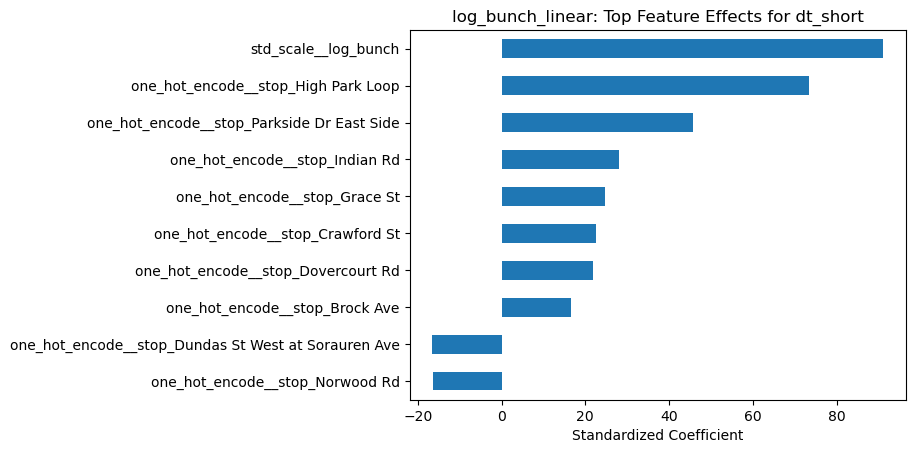

std_scale__log_bunch                                       91.076059
one_hot_encode__stop_High Park Loop                        73.404692
one_hot_encode__stop_Parkside Dr East Side                 45.646865
one_hot_encode__stop_Indian Rd                             28.032523
one_hot_encode__stop_Grace St                              24.657187
                                                             ...    
one_hot_encode__stop_Queens Park (Queen's Park Station)     0.401285
one_hot_encode__stop_Logan Ave                             -0.263247
std_scale__daylight                                         0.241820
std_scale__rain                                            -0.146143
std_scale__avg_health_index                                 0.058323
Length: 83, dtype: float64


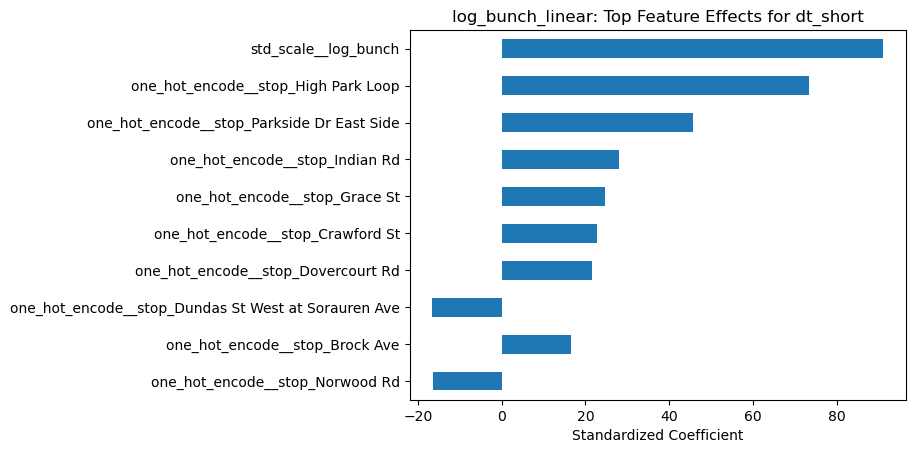

std_scale__log_bunch                                       91.089019
one_hot_encode__stop_High Park Loop                        73.530588
one_hot_encode__stop_Parkside Dr East Side                 45.650468
one_hot_encode__stop_Indian Rd                             27.993635
one_hot_encode__stop_Grace St                              25.002834
                                                             ...    
one_hot_encode__stop_Queens Park (Queen's Park Station)     0.363688
one_hot_encode__stop_Logan Ave                             -0.293098
std_scale__daylight                                         0.259212
std_scale__rain                                            -0.156662
std_scale__avg_health_index                                 0.017320
Length: 83, dtype: float64


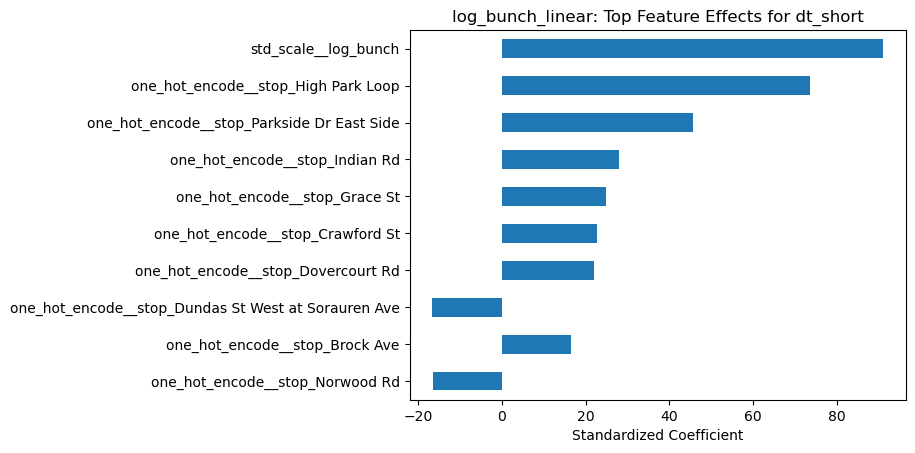

std_scale__log_bunch                          91.103536
one_hot_encode__stop_High Park Loop           73.414268
one_hot_encode__stop_Parkside Dr East Side    45.567201
one_hot_encode__stop_Indian Rd                27.960390
one_hot_encode__stop_Grace St                 24.972543
                                                ...    
one_hot_encode__stop_Prust Ave                 0.546006
one_hot_encode__stop_Logan Ave                -0.317611
std_scale__daylight                            0.273505
std_scale__rain                               -0.165376
std_scale__avg_health_index                   -0.016789
Length: 83, dtype: float64


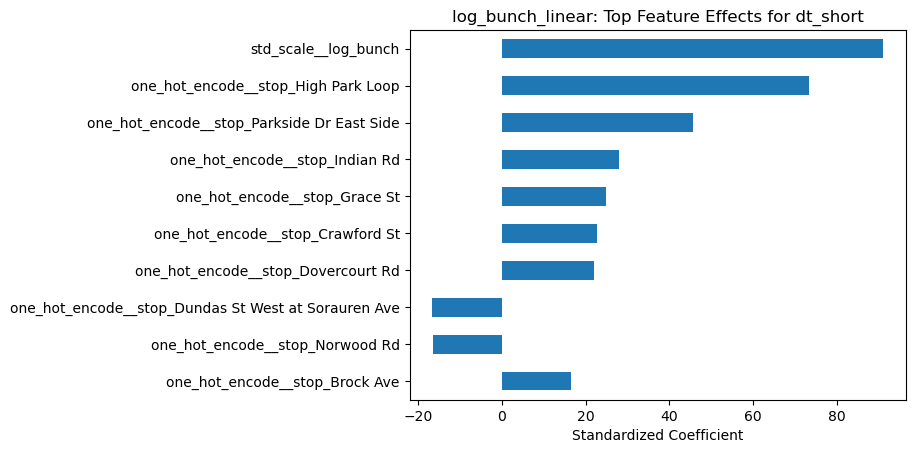

std_scale__log_bunch                          91.109588
one_hot_encode__stop_High Park Loop           73.396258
one_hot_encode__stop_Parkside Dr East Side    45.547949
one_hot_encode__stop_Indian Rd                27.934382
one_hot_encode__stop_Grace St                 24.948396
                                                ...    
one_hot_encode__stop_Prust Ave                 0.525339
std_scale__daylight                            0.285400
std_scale__rain                               -0.172530
std_scale__avg_health_index                   -0.044685
one_hot_encode__stop_Logan Ave                -0.034767
Length: 83, dtype: float64


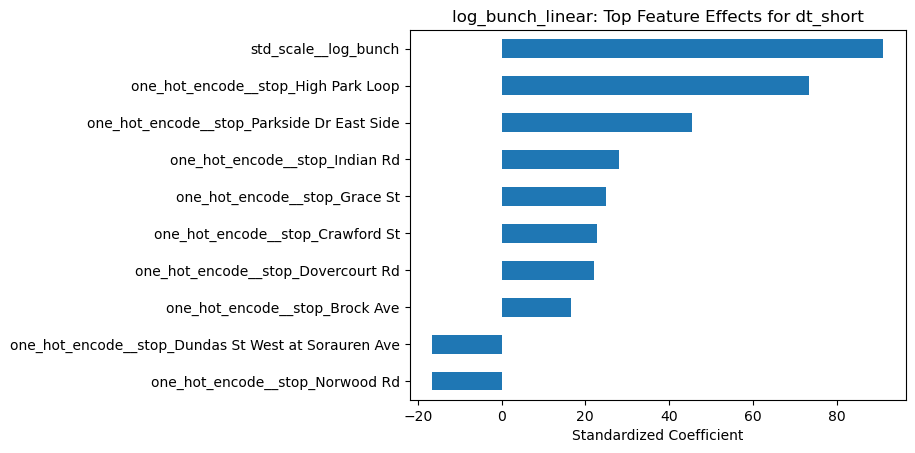

one_hot_encode__stop_High Park Loop                     108.814348
std_scale__log_bunch                                     81.611207
one_hot_encode__stop_Parkside Dr East Side               54.008103
std_scale__snow_on_ground                                51.734364
one_hot_encode__stop_Grace St                            47.520144
                                                           ...    
one_hot_encode__stop_Main St at Gerrard St East          -1.040176
one_hot_encode__stop_Gerrard St East  at Coxwell Ave     -0.993900
std_scale__avg_visibility                                -0.871638
one_hot_encode__stop_Dundas St West                      -0.591786
one_hot_encode__stop_St George St                        -0.083096
Length: 83, dtype: float64


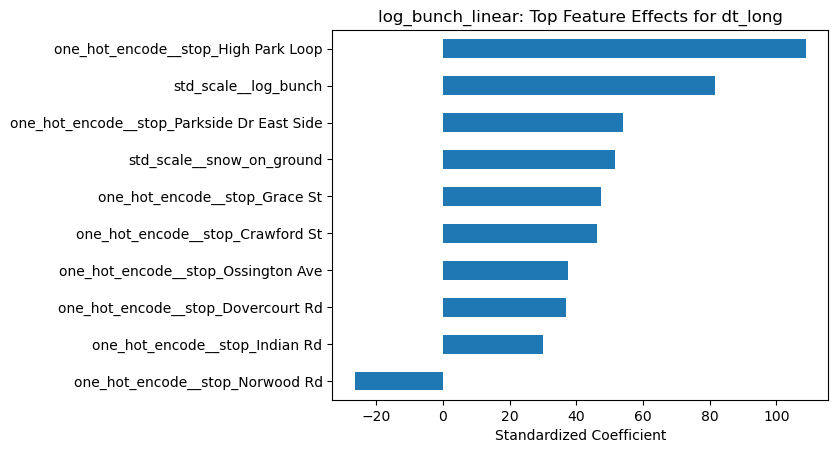

one_hot_encode__stop_High Park Loop                     108.819462
std_scale__log_bunch                                     81.596757
one_hot_encode__stop_Parkside Dr East Side               54.014533
std_scale__snow_on_ground                                51.720777
one_hot_encode__stop_Grace St                            47.531768
                                                           ...    
one_hot_encode__stop_St Matthews Rd                       1.015897
one_hot_encode__stop_Gerrard St East  at Coxwell Ave     -0.993087
std_scale__avg_visibility                                -0.875217
one_hot_encode__stop_Dundas St West                      -0.577279
one_hot_encode__stop_St George St                        -0.070598
Length: 83, dtype: float64


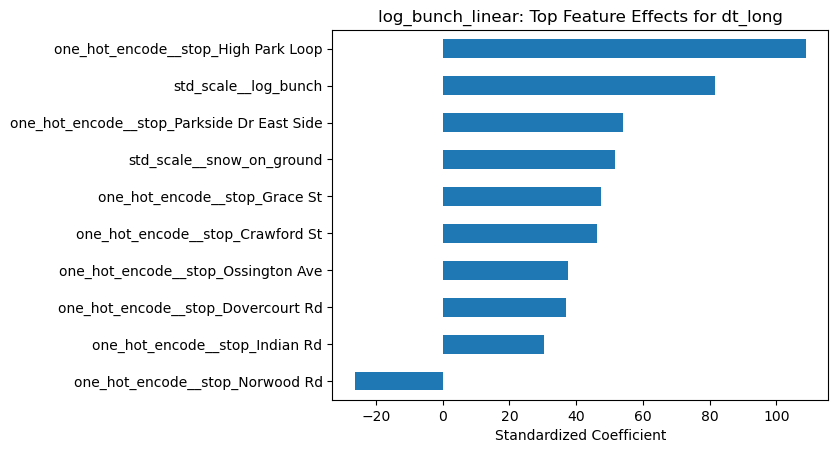

one_hot_encode__stop_High Park Loop                     109.711148
std_scale__log_bunch                                     81.612266
one_hot_encode__stop_Parkside Dr East Side               54.367008
std_scale__snow_on_ground                                51.709701
one_hot_encode__stop_Grace St                            47.628685
                                                           ...    
one_hot_encode__stop_St Matthews Rd                       1.004103
one_hot_encode__stop_Gerrard St East  at Coxwell Ave     -0.986145
std_scale__avg_visibility                                -0.872305
one_hot_encode__stop_Dundas St West                      -0.594581
one_hot_encode__stop_St George St                        -0.089983
Length: 83, dtype: float64


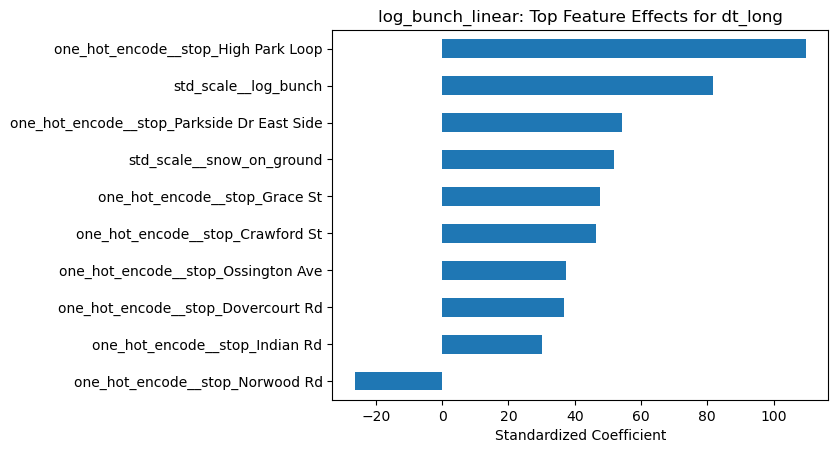

one_hot_encode__stop_High Park Loop                     109.577224
std_scale__log_bunch                                     81.587579
one_hot_encode__stop_Parkside Dr East Side               54.305271
std_scale__snow_on_ground                                51.694052
one_hot_encode__stop_Grace St                            47.651726
                                                           ...    
one_hot_encode__stop_Main St at Gerrard St East          -1.046489
one_hot_encode__stop_Gerrard St East  at Coxwell Ave     -0.985289
std_scale__avg_visibility                                -0.878380
one_hot_encode__stop_Dundas St West                      -0.735077
one_hot_encode__stop_St George St                        -0.065178
Length: 83, dtype: float64


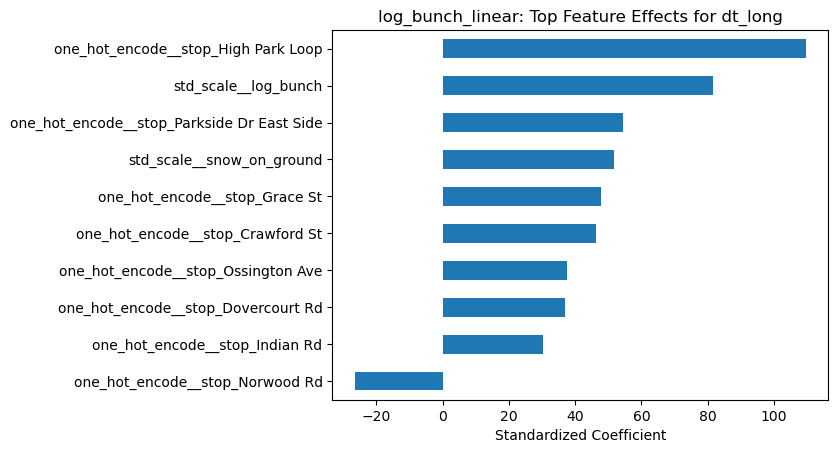

one_hot_encode__stop_High Park Loop                     109.582405
std_scale__log_bunch                                     81.572244
one_hot_encode__stop_Parkside Dr East Side               54.311777
std_scale__snow_on_ground                                51.680002
one_hot_encode__stop_Grace St                            47.663482
                                                           ...    
one_hot_encode__stop_Main St at Gerrard St East          -1.045771
one_hot_encode__stop_Gerrard St East  at Coxwell Ave     -0.989145
std_scale__avg_visibility                                -0.881449
one_hot_encode__stop_Dundas St West                      -0.720348
one_hot_encode__stop_St George St                        -0.052541
Length: 83, dtype: float64


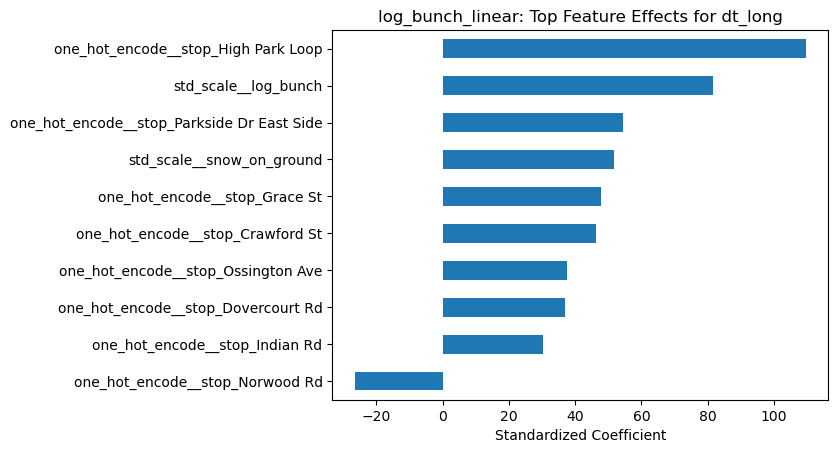

raw_linear dt_short rmse mean: 107.56882818316058
raw_linear dt_short rmse std: 18.271543425610236
raw_linear dt_short average R^2 score: 0.48597751983365856
raw_linear dt_short R^2 score std: 0.11720813373970708

raw_linear dt_long rmse mean: 76.75964037436589
raw_linear dt_long rmse std: 38.09121900977909
raw_linear dt_long average R^2 score: 0.2327711348579336
raw_linear dt_long R^2 score std: 0.3149186987121304

log_targets_linear dt_short rmse mean: 156.17566184589722
log_targets_linear dt_short rmse std: 23.160292220075178
log_targets_linear dt_short average R^2 score: -0.08300078944381677
log_targets_linear dt_short R^2 score std: 0.21605112361812048

log_targets_linear dt_long rmse mean: 94.05041275401842
log_targets_linear dt_long rmse std: 55.70875707864749
log_targets_linear dt_long average R^2 score: 0.032294456780028624
log_targets_linear dt_long R^2 score std: 0.10757069138307734

log_log_linear dt_short rmse mean: 126.21658383503666
log_log_linear dt_short rmse std: 22.7

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## Linear regression model 

## Turn stop information and direction into categorical features.
daily_df['stop']=daily_df['stop'].astype('category')
daily_df['dir']=daily_df['dir'].astype('category')

## Log Transformations of features/targets 

daily_df['log_bunch'] = np.log1p(daily_df['bunch'])
daily_df['log_dt_short'] = np.log1p(daily_df['dt_short'])
daily_df['log_dt_long'] = np.log1p(daily_df['dt_long'])

## Just in case, lets make sure the dates are in order: 
daily_df = daily_df.sort_values("date").reset_index(drop=True)

## Modeling configurations with different choices of features and transformations: 

models = {
    "raw_linear": {
        "targets": {"dt_short": "dt_short", 
                    "dt_long": "dt_long"},
        "cat features": ['dir', 'stop'],
        "num features": ['bunch', 'avg_temperature', 'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight']
    },
    "log_targets_linear": {
         "targets": {"dt_short": "log_dt_short", 
                     "dt_long": "log_dt_long"},
        "cat features": ['dir', 'stop'],
        "num features": ['bunch', 'avg_temperature', 'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight']
    }, 
    "log_log_linear": {
         "targets": {"dt_short": "log_dt_short", 
                     "dt_long": "log_dt_long"},
        "cat features": ['dir', 'stop'],
        "num features": ['log_bunch', 'avg_temperature', 'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight']
    },
    "log_bunch_linear": {
         "targets": {"dt_short": "dt_short", 
                     "dt_long": "dt_long"},
        "cat features": ['dir', 'stop'],
        "num features": ['log_bunch', 'avg_temperature', 'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight']
    }
}


lin_loss = dict()
lin_R2_score = dict()

tss = TimeSeriesSplit(n_splits=5, test_size=30)

for model_name, config in models.items():
    num_features = config["num features"]
    cat_features = config["cat features"]
    features = num_features + cat_features

    preprocessor = ColumnTransformer(
            transformers=[
                ("std_scale", StandardScaler(), num_features),
                ("one_hot_encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
            ],
            remainder="drop"
        )


    for target in ['dt_short', 'dt_long']:
        target_col = config["targets"][target]
        
        for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
            df_train = daily_df.iloc[tss_train]
            df_test = daily_df.iloc[tss_test]

            X_train = df_train[features].copy()
            X_test = df_test[features].copy()

            y_train = df_train[target_col].copy()
            y_test = df_test[target].copy()

    ## One-hot encode categorical variables

            model_pipe = Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", LinearRegression())
        ])

            
            
            model_pipe.fit(X_train, y_train)
            y_pred = model_pipe.predict(X_test)

## Back transform the transformed targets for comparison
            if "log" in target_col:
                y_pred = np.expm1(y_pred)

            lin_R2_score[(model_name, target, idx)] = r2_score(y_test, y_pred)
            lin_loss[(model_name, target, idx)] = rmse(y_test, y_pred)

            
            coefs = pd.Series(model_pipe.named_steps["model"].coef_, index=model_pipe.named_steps["preprocess"].get_feature_names_out())

            coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)
            print(coefs_sorted)

            plt.figure()
            coefs_sorted.head(10).plot(kind='barh')
            plt.title(f"{model_name}: Top Feature Effects for {target_col}")
            plt.xlabel("Standardized Coefficient")
            plt.gca().invert_yaxis()
            plt.show()

for model_name in models.keys():
    for dt in ['dt_short', 'dt_long']:


        print(f'{model_name} {dt} rmse mean: {np.array([val for key, val in lin_loss.items() if key[0] == model_name and key[1] == dt]).mean()}')
        print(f'{model_name} {dt} rmse std: {np.array([val for key, val in lin_loss.items() if key[0] == model_name and key[1] == dt]).std()}')
        print(f'{model_name} {dt} average R^2 score: {np.array([val for key, val in lin_R2_score.items() if key[0] == model_name and key[1] == dt]).mean()}')
        print(f'{model_name} {dt} R^2 score std: {np.array([val for key, val in lin_R2_score.items() if key[0] == model_name and key[1] == dt]).std()}\n')

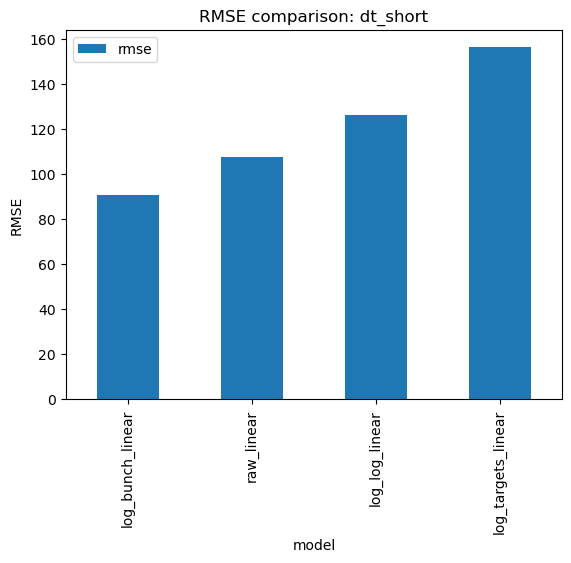

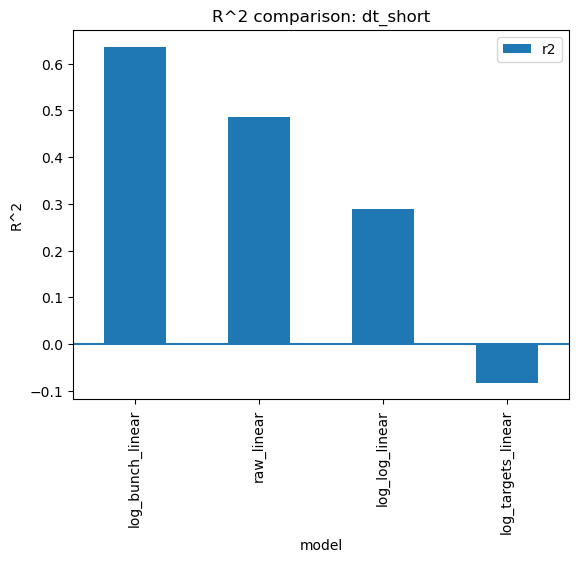

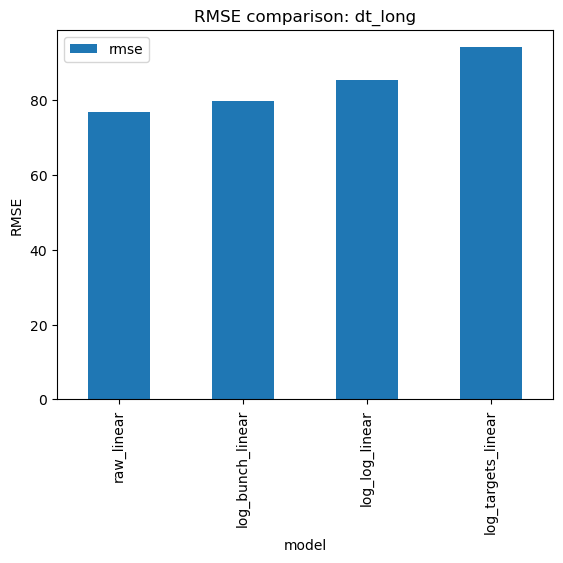

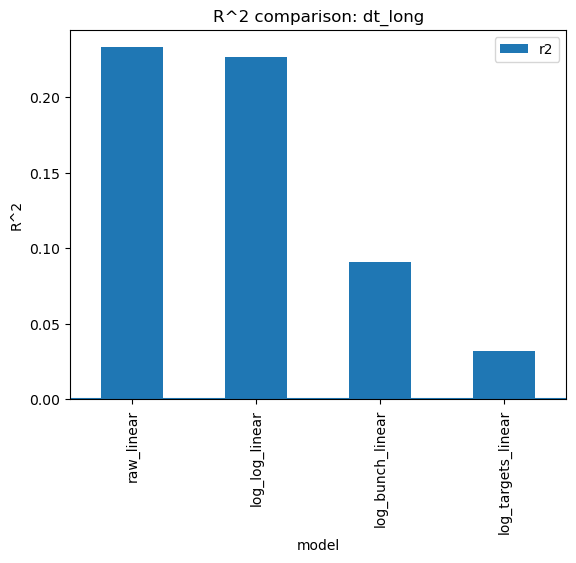

In [23]:
## This is a bit overwhelming, so I am going to plot this info in a graph instead so that we can choose the best ones to do regularization

## First, put all of the results for each model and each of the two features into a data frame 
results_dict = []

for key, val in lin_loss.items():
    results_dict.append(
        {
            "model": key[0],
            "target": key[1],
            "fold": key[2],
            "rmse": val,
            "r2": lin_R2_score[(key[0], key[1], key[2])]
        }
    )

results_df = pd.DataFrame(results_dict) 

# Next we will separate the two targets and take the average scores for each of the 4 models and plot the results. We will use this to determine the model to use for regularization
results_by_target = {}

for target in ["dt_short", "dt_long"]:
    df_target = results_df[results_df["target"] == target].copy()

    summary = (
        df_target
        .groupby("model")[["rmse", "r2"]]
        .mean()
        .reset_index()
    )

    results_by_target[target] = summary


for target, summary in results_by_target.items():
    #Sort lowest to highest
    summary_rmse = summary.sort_values("rmse", ascending=True)
    summary_rmse.plot(x = "model",y = "rmse", kind="bar")
    plt.title(f"RMSE comparison: {target}")
    plt.ylabel("RMSE")
    plt.show()

    ## Sort highest to lowest
    summary_r2 = summary.sort_values("r2", ascending=False)
    summary_r2.plot(x = "model", y = "r2", kind="bar")
    plt.title(f"R^2 comparison: {target}")
    plt.ylabel("R^2")
    plt.axhline(0)
    plt.show()


In [24]:
results_by_target

{'dt_short':                 model        rmse        r2
 0    log_bunch_linear   90.572170  0.636657
 1      log_log_linear  126.216584  0.289266
 2  log_targets_linear  156.175662 -0.083001
 3          raw_linear  107.568828  0.485978,
 'dt_long':                 model       rmse        r2
 0    log_bunch_linear  79.675943  0.090717
 1      log_log_linear  85.416810  0.226347
 2  log_targets_linear  94.050413  0.032294
 3          raw_linear  76.759640  0.232771}

In [25]:
models = {
    "raw_linear": {
        "targets": {"dt_short": "dt_short", 
                    "dt_long": "dt_long"},
        "cat features": ['dir', 'stop'],
        "num features": ['bunch', 'avg_temperature', 'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight']
    },
    "log_log_linear": {
         "targets": {"dt_long": "log_dt_long"},
        "cat features": ['dir', 'stop'],
        "num features": ['log_bunch', 'avg_temperature', 'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight']
    },
    "log_bunch_linear": {
         "targets": {"dt_short": "dt_short", 
                     "dt_long": "dt_long"},
        "cat features": ['dir', 'stop'],
        "num features": ['log_bunch', 'avg_temperature', 'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight']
    }
}

In [26]:
## Next we will do some Ridge and Lasso regularization


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


reg_loss = dict()
reg_R2_score = dict()

num_splits = 5
outer_cv = TimeSeriesSplit(n_splits=num_splits, test_size=30)
inner_cv = TimeSeriesSplit(n_splits=3)

nested_results = []
best_params = {}

for model_name, config in models.items():
    num_features = config["num features"]
    cat_features = config["cat features"]
    features = num_features + cat_features

    preprocessor = ColumnTransformer(
        transformers=[
            ("std_scale", StandardScaler(), num_features),
            ("one_hot_encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
        ],
        remainder="drop"
    )

    ridge_pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", Ridge())
    ])

    lasso_pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", Lasso(max_iter=10000))
    ])
    
    ridge_grid = {
            "model__alpha": np.logspace(-3, 3, 13)
        }

    lasso_grid = {
            "model__alpha": np.logspace(-3, 0, 9)
        }



    for target_name, target_col in config["targets"].items():
        # To store the best parameters
        best_params[("ridge_tuned", model_name, target_name)] = []
        best_params[("lasso_tuned", model_name, target_name)] = []

    # Outer Folds
        for fold, (outer_train_idx, outer_test_idx) in enumerate(outer_cv.split(daily_df), start=1):
            df_train = daily_df.iloc[outer_train_idx]
            df_test = daily_df.iloc[outer_test_idx]

            X_train = df_train[features].copy()
            X_test = df_test[features].copy()

            y_train = df_train[target_col].copy()
            y_test = df_test[target_name].copy()

    ## Ridge with inner tuning

            ridge_search = GridSearchCV(
                estimator=ridge_pipe,
                param_grid=ridge_grid,
                scoring="neg_root_mean_squared_error",
                cv=inner_cv,
                n_jobs=-1
            )
            ridge_search.fit(X_train, y_train)
            y_pred_ridge = ridge_search.best_estimator_.predict(X_test)

            # Back-transform if needed
            if "log" in target_col:
                y_pred_ridge = np.expm1(y_pred_ridge)

            ridge_rmse = rmse(y_test, y_pred_ridge)
            ridge_r2 = r2_score(y_test, y_pred_ridge)

            nested_results.append({
                "regularization": "ridge_tuned",
                "model": model_name,
                "target": target_name,
                "fold": fold,
                "rmse": ridge_rmse,
                "r2": ridge_r2
            })

            best_params[("ridge_tuned", model_name, target_name)].append(ridge_search.best_params_)



    ## Lasso with inner tuning
            lasso_search = GridSearchCV(
                estimator=lasso_pipe,
                param_grid=lasso_grid,
                scoring="neg_root_mean_squared_error",
                cv=inner_cv,
                n_jobs=-1
            )
            lasso_search.fit(X_train, y_train)
            y_pred_lasso = lasso_search.best_estimator_.predict(X_test)

            # Back-transform if needed
            if "log" in target_col:
                y_pred_lasso = np.expm1(y_pred_lasso)

            lasso_rmse = rmse(y_test, y_pred_lasso)
            lasso_r2 = r2_score(y_test, y_pred_lasso)

            nested_results.append({
                "regularization": "lasso_tuned",
                "model": model_name,
                "target": target_name,
                "fold": fold,
                "rmse": lasso_rmse,
                "r2": lasso_r2
            })

            best_params[("lasso_tuned", model_name, target_name)].append(lasso_search.best_params_)

            print(
                f"{model_name}, {target_name}, Fold {fold}: "
                f"ridge RMSE={ridge_rmse:.2f}, ridge R^2={ridge_r2:.2f}, "
                f"best alpha={ridge_search.best_params_['model__alpha']}; "
                f"lasso RMSE={lasso_rmse:.2f}, lasso R^2={lasso_r2:.2f}, "
                f"best alpha={lasso_search.best_params_['model__alpha']}"
            )

nested_results_df = pd.DataFrame(nested_results)

final_reg_summary = (
    nested_results_df
    .groupby(["regularization", "model", "target"])
    .agg(
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        mean_r2=("r2", "mean"),
        std_r2=("r2", "std")
    )
    .reset_index()
)
## Summary for the outer Folds

alpha_summary = []
for key, val in best_params.items():
    alphas = [d["model__alpha"] for d in val]
    
    alpha_summary.append({
        "regularization": key[0],
        "model": key[1],
        "target": key[2],
        "mean_alpha": np.mean(alphas),
        "std_alpha": np.std(alphas),
        "all_alphas": alphas
    })

alpha_df = pd.DataFrame(alpha_summary)


raw_linear, dt_short, Fold 1: ridge RMSE=87.27, ridge R^2=0.62, best alpha=100.0; lasso RMSE=88.20, lasso R^2=0.61, best alpha=0.07498942093324558
raw_linear, dt_short, Fold 2: ridge RMSE=131.71, ridge R^2=0.42, best alpha=100.0; lasso RMSE=132.58, lasso R^2=0.41, best alpha=0.07498942093324558
raw_linear, dt_short, Fold 3: ridge RMSE=124.07, ridge R^2=0.32, best alpha=100.0; lasso RMSE=125.58, lasso R^2=0.30, best alpha=0.07498942093324558
raw_linear, dt_short, Fold 4: ridge RMSE=108.97, ridge R^2=0.45, best alpha=100.0; lasso RMSE=110.16, lasso R^2=0.44, best alpha=0.07498942093324558
raw_linear, dt_short, Fold 5: ridge RMSE=87.28, ridge R^2=0.61, best alpha=100.0; lasso RMSE=87.52, lasso R^2=0.61, best alpha=0.07498942093324558
raw_linear, dt_long, Fold 1: ridge RMSE=63.15, ridge R^2=0.47, best alpha=0.001; lasso RMSE=63.16, lasso R^2=0.47, best alpha=0.001


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


raw_linear, dt_long, Fold 2: ridge RMSE=151.14, ridge R^2=0.39, best alpha=0.001; lasso RMSE=151.16, lasso R^2=0.39, best alpha=0.001


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


raw_linear, dt_long, Fold 3: ridge RMSE=70.78, ridge R^2=0.30, best alpha=0.001; lasso RMSE=70.79, lasso R^2=0.30, best alpha=0.001


...

log_bunch_linear, dt_short, Fold 2: ridge RMSE=115.22, ridge R^2=0.55, best alpha=316.22776601683796; lasso RMSE=118.58, lasso R^2=0.53, best alpha=0.4216965034285822
log_bunch_linear, dt_short, Fold 3: ridge RMSE=102.34, ridge R^2=0.54, best alpha=316.22776601683796; lasso RMSE=103.88, lasso R^2=0.52, best alpha=0.4216965034285822
log_bunch_linear, dt_short, Fold 4: ridge RMSE=89.37, ridge R^2=0.63, best alpha=316.22776601683796; lasso RMSE=89.52, lasso R^2=0.63, best alpha=0.4216965034285822
log_bunch_linear, dt_short, Fold 5: ridge RMSE=73.12, ridge R^2=0.73, best alpha=316.22776601683796; lasso RMSE=73.61, lasso R^2=0.72, best alpha=0.4216965034285822


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


log_bunch_linear, dt_long, Fold 1: ridge RMSE=65.95, ridge R^2=0.43, best alpha=0.001; lasso RMSE=65.96, lasso R^2=0.43, best alpha=0.001
log_bunch_linear, dt_long, Fold 2: ridge RMSE=146.02, ridge R^2=0.43, best alpha=0.001; lasso RMSE=146.04, lasso R^2=0.43, best alpha=0.001
log_bunch_linear, dt_long, Fold 3: ridge RMSE=76.23, ridge R^2=0.18, best alpha=0.001; lasso RMSE=76.23, lasso R^2=0.18, best alpha=0.001
log_bunch_linear, dt_long, Fold 4: ridge RMSE=52.94, ridge R^2=0.31, best alpha=0.001; lasso RMSE=52.94, lasso R^2=0.31, best alpha=0.001


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


log_bunch_linear, dt_long, Fold 5: ridge RMSE=57.24, ridge R^2=-0.90, best alpha=0.001; lasso RMSE=57.22, lasso R^2=-0.90, best alpha=0.001


In [27]:
ols_summary = summary.reset_index().rename(columns={
    "index": "model",
    "rmse": "mean_rmse",
    "r2": "mean_r2"
})

ols_summary["regularization"] = "none"

combined_summary = pd.concat([final_reg_summary, ols_summary])
combined_summary

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [ ]:
## This is a bit overwhelming, so I am going to plot this info in a graph instead so that we can choose the best ones to do regularization



# Next we will separate the two targets and take the average scores for each of the 4 models and plot the results. We will use this to determine the model to use for regularization

for target in ["dt_short", "dt_long"]:
    target_df = results_df[results_df["target"] == target]

    summary = (
        target_df
        .groupby(["model"])[["rmse", "r2"]]
        .mean()
    )

    #Sort lowest to highest
    summary_rmse = summary.sort_values("rmse", ascending=True)
    summary_rmse["rmse"].plot(kind="bar")
    plt.title(f"RMSE comparison: {target}")
    plt.ylabel("RMSE")
    plt.show()

    ## Sort highest to lowest
    summary_r2 = summary.sort_values("r2", ascending=False)
    summary_r2["r2"].plot(kind="bar")
    plt.title(f"R^2 comparison: {target}")
    plt.ylabel("R^2")
    plt.axhline(0)
    plt.show()


In [ ]:
comparison = final_reg_summary.pivot_table(
    index=["model", "target"],
    columns="regularization",
    values="mean_rmse"
)

final_reg_summary

,regularization,model,target,mean_rmse,std_rmse,mean_r2,std_r2
0,lasso_tuned,log_bunch_linear,dt_long,81.734983,32.138915,-0.033725,0.737593
1,lasso_tuned,log_bunch_linear,dt_short,92.350146,24.441000,0.622776,0.109509
2,lasso_tuned,log_log_linear,dt_long,87.593804,57.695365,0.183529,0.151252
3,lasso_tuned,raw_linear,dt_long,79.196824,35.959674,0.142824,0.384707
4,lasso_tuned,raw_linear,dt_short,108.684855,25.804188,0.476842,0.129529
5,ridge_tuned,log_bunch_linear,dt_long,81.733233,32.132631,-0.033690,0.737422
6,ridge_tuned,log_bunch_linear,dt_short,90.662999,23.224910,0.636354,0.100351
7,ridge_tuned,log_log_linear,dt_long,87.477351,57.708710,0.186161,0.149999
8,ridge_tuned,raw_linear,dt_long,79.193650,35.951342,0.142763,0.384938
9,ridge_tuned,raw_linear,dt_short,107.747461,25.293551,0.485828,0.124696


In [ ]:
## Now we will look at the alphas for the log_bunch_linear model (best for dt_short) and raw_linear model (best for dt_long)

## for dt_short, ridge seems to improve things more than lasso for both log_bunch and raw_linear, but dt_long doesn't really benefit from either. 

## However, for dt_short the ridge doesn't actually improve the scores compared to the initial model.... so let's just proceed without the regularization. 

In [ ]:

## One Last thing I will do is try to prune the features a bit in line with the XGBoost pruning 


filtered_models = {
    "raw_linear": {
        "targets": {"dt_short": "dt_short", 
                    "dt_long": "dt_long"},
        "features": ['bunch', 'avg_wind_speed', 
                     'avg_visibility', 'avg_health_index', 
                     'rain', 'snow_on_ground', 'daylight', 
                     'dir', 'stop']
    },
    
    "log_bunch_linear": {
         "targets": {"dt_short": "dt_short", 
                     "dt_long": "dt_long"},
        "features": ['log_bunch', 'avg_wind_speed', 
                     'avg_visibility', 'avg_health_index', 
                     'rain', 'snow_on_ground', 'daylight', 
                     'dir', 'stop']
    }
}


filt_lin_loss = dict()
filt_lin_R2_score = dict()

## Just in case, lets make sure the dates are in order: 

daily_df = daily_df.sort_values("date").reset_index(drop=True)


for model_name, config in filtered_models.items():
    features = config["features"]
    
    for target in ['dt_short', 'dt_long']:
        target_col = config["targets"][target]
        
        for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
            df_train = daily_df.iloc[tss_train]
            df_test = daily_df.iloc[tss_test]

            X_train = df_train[features].copy()
            X_test = df_test[features].copy()

            y_train = df_train[target_col].copy()
            y_test = df_test[target].copy()

    ## One-hot encode categorical variables

            X_train = pd.get_dummies(X_train, columns=['dir','stop'], drop_first=False)
            X_test = pd.get_dummies(X_test, columns=['dir','stop'], drop_first=False)

    ## Make sure the columns line up 
            X_test = X_test.reindex(columns=X_train.columns, fill_value = 0)

            
            model = LinearRegression()
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

## Back transform the transformed targets for comparison
            if "log" in target_col:
                y_pred = np.expm1(y_pred)

            filt_lin_R2_score[(model_name, target, idx)] = r2_score(y_test, y_pred)
            filt_lin_loss[(model_name, target, idx)] = rmse(y_test, y_pred)
       

for model_name in filtered_models.keys():
    for dt in ['dt_short', 'dt_long']:
        print(f'{model_name} {dt} rmse mean: {np.array([val for key, val in filt_lin_loss.items() if key[0] == model_name and key[1] == dt]).mean()}')
        print(f'{model_name} {dt} rmse std: {np.array([val for key, val in filt_lin_loss.items() if key[0] == model_name and key[1] == dt]).std()}')
        print(f'{model_name} {dt} average R^2 score: {np.array([val for key, val in filt_lin_R2_score.items() if key[0] == model_name and key[1] == dt]).mean()}')
        print(f'{model_name} {dt} R^2 score std: {np.array([val for key, val in filt_lin_R2_score.items() if key[0] == model_name and key[1] == dt]).std()}\n')


raw_linear dt_short rmse mean: 107.46628656922451
raw_linear dt_short rmse std: 14.963121490246069
raw_linear dt_short average R^2 score: 0.48553050596826725
raw_linear dt_short R^2 score std: 0.09740863772162943

raw_linear dt_long rmse mean: 78.40978820857927
raw_linear dt_long rmse std: 36.94736727966232
raw_linear dt_long average R^2 score: -0.137742618201048
raw_linear dt_long R^2 score std: 0.5950787783146922

log_bunch_linear dt_short rmse mean: 90.22173992038158
log_bunch_linear dt_short rmse std: 12.979369443220856
log_bunch_linear dt_short average R^2 score: 0.6383558709308652
log_bunch_linear dt_short R^2 score std: 0.06550806217772319

log_bunch_linear dt_long rmse mean: 81.96434569005993
log_bunch_linear dt_long rmse std: 32.23148584598032
log_bunch_linear dt_long average R^2 score: -0.4267705745056343
log_bunch_linear dt_long R^2 score std: 0.901194485412403



In [ ]:
print(results_df.head(10))
print(results_df["model"].unique())


        model    target  fold        rmse        r2
0  raw_linear  dt_short     0   86.512671  0.627962
1  raw_linear  dt_short     1  130.901134  0.423924
2  raw_linear  dt_short     2  124.044085  0.318139
3  raw_linear  dt_short     3  109.015477  0.450418
4  raw_linear  dt_short     4   87.370774  0.609445
5  raw_linear   dt_long     0   63.149914  0.473941
6  raw_linear   dt_long     1  151.138695  0.394665
7  raw_linear   dt_long     2   70.783888  0.296201
8  raw_linear   dt_long     3   49.786438  0.385959
9  raw_linear   dt_long     4   48.939267 -0.386911
<ArrowStringArray>
['raw_linear', 'log_targets_linear', 'log_log_linear', 'log_bunch_linear']
Length: 4, dtype: str


              model feature_set        rmse        r2  \
0  log_bunch_linear        full   90.572170  0.636657   
1  log_bunch_linear     reduced   90.221740  0.638356   
2        raw_linear        full  107.568828  0.485978   
3        raw_linear     reduced  107.466287  0.485531   

                        label  
0     log_bunch_linear (full)  
1  log_bunch_linear (reduced)  
2           raw_linear (full)  
3        raw_linear (reduced)  


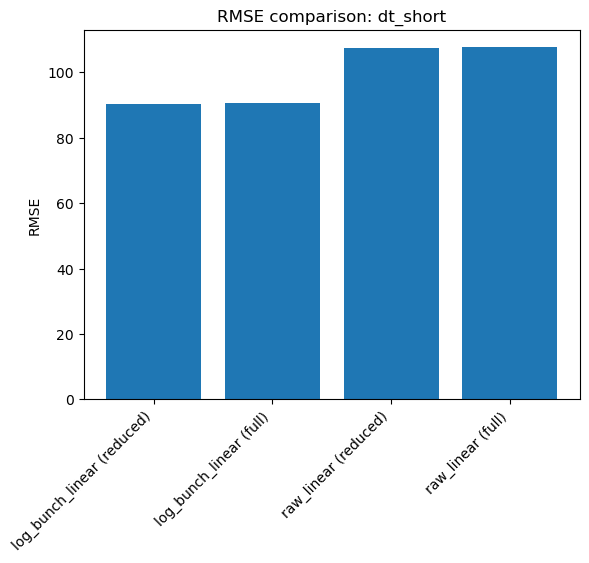

              model feature_set        rmse        r2  \
1  log_bunch_linear     reduced   90.221740  0.638356   
0  log_bunch_linear        full   90.572170  0.636657   
3        raw_linear     reduced  107.466287  0.485531   
2        raw_linear        full  107.568828  0.485978   

                        label  
1  log_bunch_linear (reduced)  
0     log_bunch_linear (full)  
3        raw_linear (reduced)  
2           raw_linear (full)  


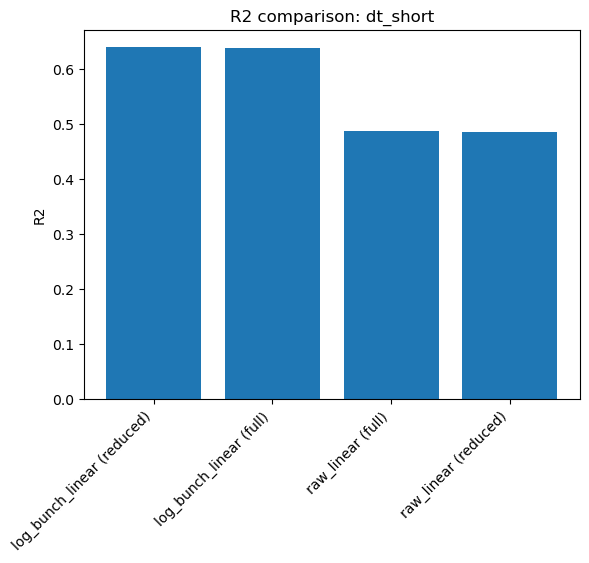

              model feature_set        rmse        r2  \
1  log_bunch_linear     reduced   90.221740  0.638356   
0  log_bunch_linear        full   90.572170  0.636657   
2        raw_linear        full  107.568828  0.485978   
3        raw_linear     reduced  107.466287  0.485531   

                        label  
1  log_bunch_linear (reduced)  
0     log_bunch_linear (full)  
2           raw_linear (full)  
3        raw_linear (reduced)  
              model feature_set       rmse        r2  \
0  log_bunch_linear        full  79.675943  0.090717   
1  log_bunch_linear     reduced  81.964346 -0.426771   
2        raw_linear        full  76.759640  0.232771   
3        raw_linear     reduced  78.409788 -0.137743   

                        label  
0     log_bunch_linear (full)  
1  log_bunch_linear (reduced)  
2           raw_linear (full)  
3        raw_linear (reduced)  


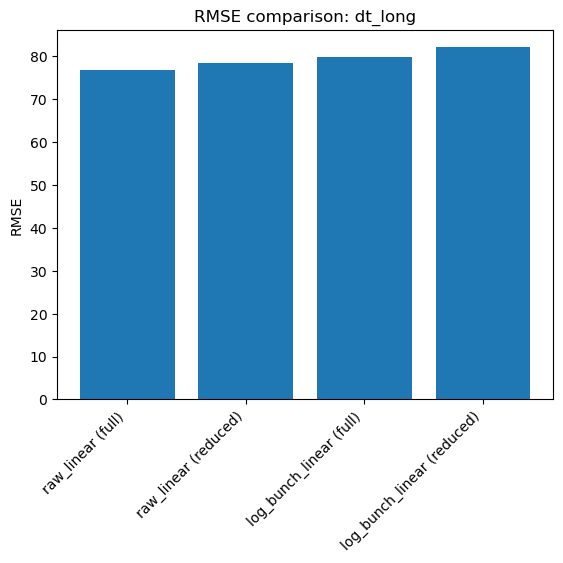

              model feature_set       rmse        r2  \
2        raw_linear        full  76.759640  0.232771   
3        raw_linear     reduced  78.409788 -0.137743   
0  log_bunch_linear        full  79.675943  0.090717   
1  log_bunch_linear     reduced  81.964346 -0.426771   

                        label  
2           raw_linear (full)  
3        raw_linear (reduced)  
0     log_bunch_linear (full)  
1  log_bunch_linear (reduced)  


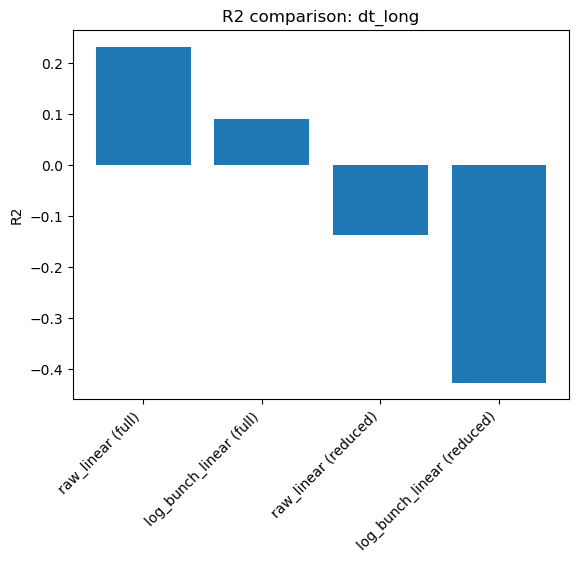

              model feature_set       rmse        r2  \
2        raw_linear        full  76.759640  0.232771   
0  log_bunch_linear        full  79.675943  0.090717   
3        raw_linear     reduced  78.409788 -0.137743   
1  log_bunch_linear     reduced  81.964346 -0.426771   

                        label  
2           raw_linear (full)  
0     log_bunch_linear (full)  
3        raw_linear (reduced)  
1  log_bunch_linear (reduced)  


In [ ]:
## First build a data frame for the two models we chose earlier along with the results

filt_results_dict = []

for key, val in filt_lin_loss.items():
    filt_results_dict.append(
        {
            "model": key[0],
            "target": key[1],
            "fold": key[2],
            "rmse": val,
            "r2": filt_lin_R2_score[(key[0], key[1], key[2])],
            "feature_set": "reduced"
        }
    )

filt_results_df = pd.DataFrame(filt_results_dict)


## Now build a dataframe for the original full-feature models but only for the two we decided to focus on
full_results_dict = []

for key, val in lin_loss.items():
    if key[0] in ["raw_linear", "log_bunch_linear"]:
        full_results_dict.append(
            {
                "model": key[0],
                "target": key[1],
                "fold": key[2],
                "rmse": val,
                "r2": lin_R2_score[(key[0], key[1], key[2])],
                "feature_set": "full"
            }
        )

full_results_df = pd.DataFrame(full_results_dict)


## Combine the two
combined_results_df = pd.concat(
    [full_results_df, filt_results_df],
    ignore_index=True
)

# Next we will separate the two targets and take the average scores for each of the 4 models and plot the results. We will use this to determine the model to use for regularization

for target in ["dt_short", "dt_long"]:
    target_df = combined_results_df[combined_results_df["target"] == target].copy()

    summary = (
        target_df
        .groupby(["model", "feature_set"])[["rmse", "r2"]]
        .mean()
        .reset_index()
    )

    summary["label"] = summary["model"] + " (" + summary["feature_set"] + ")"
    print(summary)

    #Sort lowest to highest
    summary_rmse = summary.sort_values("rmse", ascending=True)
    plt.bar(summary_rmse["label"], summary_rmse["rmse"])
    plt.title(f"RMSE comparison: {target}")
    plt.ylabel("RMSE")
    plt.xticks(rotation=45, ha='right')
    plt.show()
    print(summary_rmse)

    ## Sort highest to lowest
    summary_r2 = summary.sort_values("r2", ascending=False)
    plt.bar(summary_r2["label"], summary_r2["r2"])
    plt.title(f"R2 comparison: {target}")
    plt.ylabel("R2")
    plt.xticks(rotation=45, ha='right')
    plt.show()
    print(summary_r2)

In [ ]:
## This doesn't seem to make a difference for dt_short and while the R^2 score for the dt_long log_bunch model seems to do a bit better, the other models do much worse with this reduction so lets not change these either and stick with the entire feature set we had initially. 

## So based on everything we've seen so far it looks like the best models are log_bunch_linear for dt_short and raw_linear for dt_long with no regularization. Lets build our final model and train on the entire training set now


In [ ]:
final_models = {
    "raw_linear": {
        "target": {"dt_long": "dt_long"},
        "features": ['bunch', 
                     'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight', 'dir', 'stop']
    },
    "log_bunch_linear": {
         "target": {"dt_short": "dt_short"},
        "features": ['log_bunch', 
                     'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight', 'dir', 'stop']
    }
}





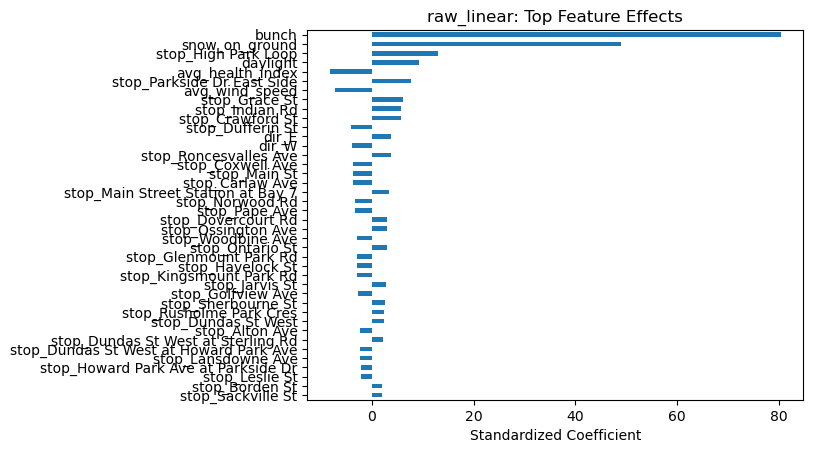

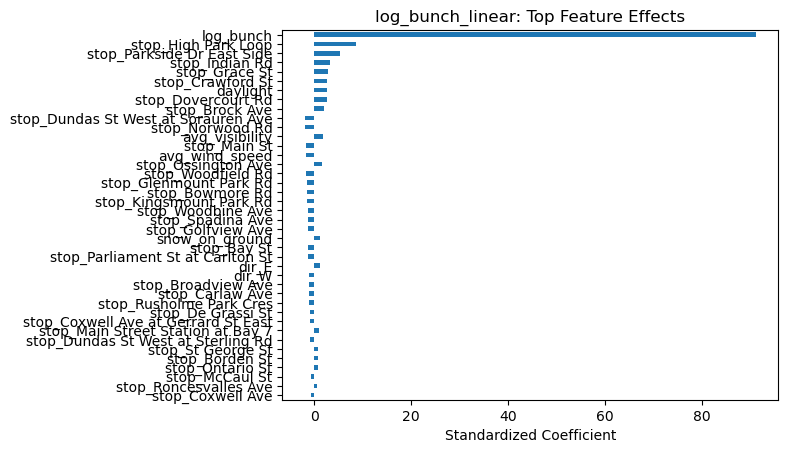

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

final_models = {
    "raw_linear": {
        "target": {"dt_long": "dt_long"},
        "features": ['bunch', 
                     'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight', 'dir', 'stop']
    },
    "log_bunch_linear": {
        "target": {"dt_short": "dt_short"},
        "features": ['log_bunch', 
                     'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight', 'dir', 'stop']
    }
}

for model_name, config in final_models.items():
    
    target_col = list(config["target"].values())[0]
    feature_cols = config["features"]
    
    # --- Prepare data ---
    X = daily_df[feature_cols].copy()
    y = daily_df[target_col]
    
    # One-hot encode categorical variables
    X = pd.get_dummies(X, drop_first=False)
    
    # --- Standardize features (important for comparing magnitudes) ---
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # --- Fit model ---
    model = LinearRegression()
    model.fit(X_scaled, y)
    
    # --- Extract coefficients ---
    coefs = pd.Series(model.coef_, index=X.columns)
    
    # Sort by absolute magnitude
    coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)
    
    # --- Plot ---
    plt.figure()
    coefs_sorted.head(40).plot(kind='barh')
    plt.title(f"{model_name}: Top Feature Effects")
    plt.xlabel("Standardized Coefficient")
    plt.gca().invert_yaxis()
    plt.show()

We use xgboost since it's a very flexible model that generalizes well. According to (https://stats.stackexchange.com/questions/338904/measures-of-ordinal-classification-error-for-ordinal-regression)[this post on Cross Validated], RMSE is the best measure of performance for ordinal classification when the classes are reasonably balanced, and MAE should not be used. Note that 'dt_long' is *not* balanced, and so we will have to come to an analysis of this with a different metric.

In [ ]:
# Let's try xgboost since it is a very flexible model
import xgboost as xgb
# First turn stop into a categorical feature.
daily_df['stop']=daily_df['stop'].astype('category')
daily_df['dir']=daily_df['dir'].astype('category')

loss = dict()
R2_score = dict()
features = ['bunch', 'gap', 'avg_temperature', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain',
            'snow_on_ground',
            'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
for target in ['dt_short', 'dt_long']:
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=200,
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=10,
                                reg_alpha=2,
                                reg_lambda=0,
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[target,idx] = r2_score(y_test, y_pred)
        loss[target,idx] = rmse(y_test, y_pred)

for dt in ['dt_short', 'dt_long']:
    print(f'{dt} rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
    print(f'{dt} rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
    print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
    print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')

dt_short rmse mean: 58.798915725531856
dt_short rmse std: 13.09872121588919
dt_short average R^2 score: 0.8378409350215339
dt_short R^2 score std: 0.07303505630187666

dt_long rmse mean: 66.95972016720661
dt_long rmse std: 37.186182473575265
dt_long average R^2 score: 0.29623802176661646
dt_long R^2 score std: 0.2716814998971146

